In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!pip install -q kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("himadri07/ciciot2023")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:10])
    print("-" * 50)

Using Colab cache for faster access to the 'ciciot2023' dataset.
Dataset path: /kaggle/input/ciciot2023
/kaggle/input/ciciot2023
[]
--------------------------------------------------
/kaggle/input/ciciot2023/CICIOT23
[]
--------------------------------------------------
/kaggle/input/ciciot2023/CICIOT23/validation
['validation.csv']
--------------------------------------------------
/kaggle/input/ciciot2023/CICIOT23/test
['test.csv']
--------------------------------------------------
/kaggle/input/ciciot2023/CICIOT23/train
['train.csv']
--------------------------------------------------


In [9]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/ciciot2023/CICIOT23/validation/validation.csv
/kaggle/input/ciciot2023/CICIOT23/test/test.csv
/kaggle/input/ciciot2023/CICIOT23/train/train.csv


In [10]:
import pandas as pd
import glob

csv_files = glob.glob(path + "/**/*.csv", recursive=True)

print("CSV Count:", len(csv_files))
print(csv_files[:5])

df = pd.read_csv(csv_files[0])

print(df.shape)
print(df.head())
print(df.columns.tolist())

CSV Count: 3
['/kaggle/input/ciciot2023/CICIOT23/validation/validation.csv', '/kaggle/input/ciciot2023/CICIOT23/test/test.csv', '/kaggle/input/ciciot2023/CICIOT23/train/train.csv']
(1176851, 47)
   flow_duration  Header_Length  Protocol Type  Duration       Rate  \
0       0.000000          53.46           5.94     63.36   3.917327   
1       0.000000          54.00           6.00     64.00  18.522314   
2       0.000000           0.00           0.98     62.72  26.927732   
3       0.004975          60.56           6.00     64.00   1.927037   
4      53.269357     2345336.20           6.00     62.80  56.269610   

       Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  \
0   3.917327    0.0              0.0              0.0              0.0  ...   
1  18.522314    0.0              0.0              0.0              0.0  ...   
2  26.927732    0.0              0.0              0.0              0.0  ...   
3   1.927037    0.0              0.0              1.0         

In [11]:
import glob

csv_files = glob.glob(path + "/**/*.csv", recursive=True)

print("Total CSV files:", len(csv_files))

for f in csv_files[:20]:
    print(f)

Total CSV files: 3
/kaggle/input/ciciot2023/CICIOT23/validation/validation.csv
/kaggle/input/ciciot2023/CICIOT23/test/test.csv
/kaggle/input/ciciot2023/CICIOT23/train/train.csv


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

df = pd.read_csv(
    "/kaggle/input/ciciot2023/CICIOT23/train/train.csv"
)

df["attack"] = (
    df["label"] != "BenignTraffic"
).astype(int)

X = df.drop(
    columns=[
        "label",
        "attack"
    ]
)

y = df["attack"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.9968563221791796
Precision: 0.9990029593808639
Recall   : 0.9977761968210337
F1 Score : 0.9983892012574773
ROC AUC  : 0.999603230684531


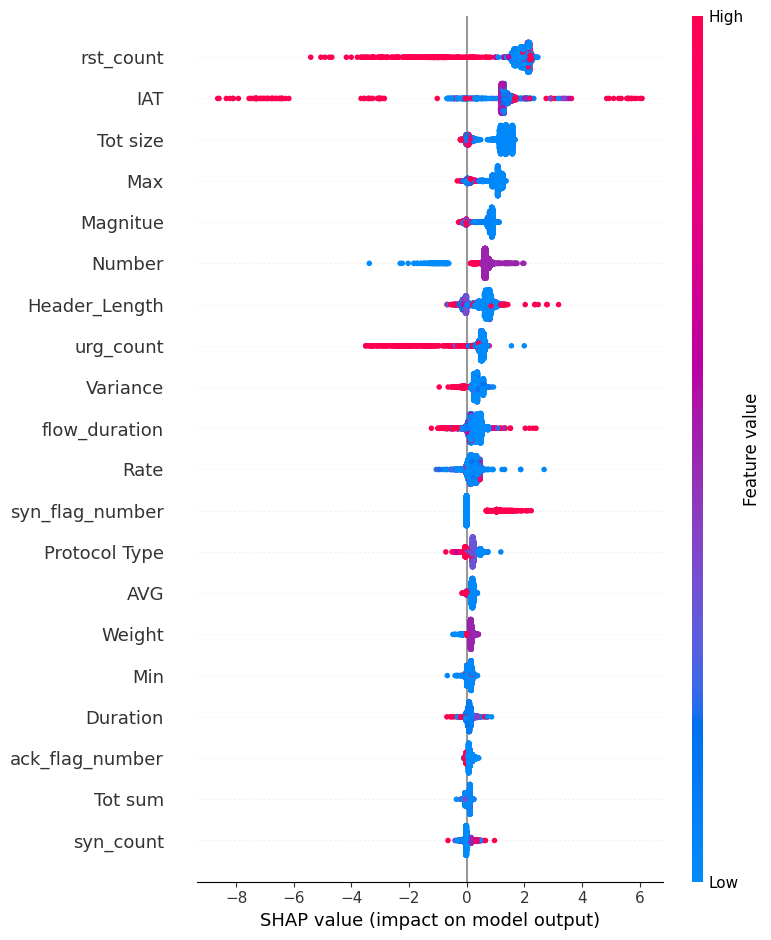

In [13]:
!pip install -q shap

import shap

sample = X_test.sample(
    n=5000,
    random_state=42
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample
)

In [14]:
shap_importance = pd.DataFrame(
    {
        "feature": sample.columns,
        "importance": abs(shap_values).mean(axis=0)
    }
)

print(
    shap_importance.sort_values(
        by="importance",
        ascending=False
    ).head(20)
)

            feature  importance
18        rst_count    1.909431
39              IAT    1.383002
38         Tot size    1.096481
35              Max    0.857724
41         Magnitue    0.712160
40           Number    0.691039
1     Header_Length    0.583887
17        urg_count    0.571722
44         Variance    0.352014
0     flow_duration    0.301490
4              Rate    0.234501
8   syn_flag_number    0.231023
2     Protocol Type    0.223651
36              AVG    0.171175
45           Weight    0.157108
34              Min    0.124864
3          Duration    0.105923
11  ack_flag_number    0.105717
33          Tot sum    0.077939
15        syn_count    0.065750


In [15]:
attack_prob = model.predict_proba(X_test)[:,1]

trust_score = 1 - attack_prob

trust_df = pd.DataFrame({
    "trust_score": trust_score,
    "attack_probability": attack_prob
})

print(trust_df.head())
print(trust_df.describe())

    trust_score  attack_probability
0  1.192093e-07             1.00000
1  9.991699e-01             0.00083
2  2.384186e-07             1.00000
3  2.384186e-07             1.00000
4  2.384186e-07             1.00000
        trust_score  attack_probability
count  1.098395e+06        1.098395e+06
mean   2.368511e-02        9.763150e-01
std    1.438718e-01        1.438708e-01
min    0.000000e+00        3.261992e-05
25%    2.384186e-07        9.999994e-01
50%    3.576279e-07        9.999996e-01
75%    5.960464e-07        9.999998e-01
max    9.999674e-01        1.000000e+00


In [16]:
print(df["attack"].value_counts())

print(df["attack"].value_counts(normalize=True))

attack
1    5362433
0     129538
Name: count, dtype: int64
attack
1    0.976413
0    0.023587
Name: proportion, dtype: float64


In [17]:
attack_prob = model.predict_proba(X_test)[:,1]

def trust_mapper(p):
    if p < 0.2:
        return 1.0
    elif p < 0.4:
        return 0.8
    elif p < 0.6:
        return 0.6
    elif p < 0.8:
        return 0.4
    else:
        return 0.2

trust_score = [trust_mapper(p) for p in attack_prob]

In [18]:
import numpy as np

trust_score = 1 - attack_prob

trust_score = (
    trust_score - trust_score.min()
) / (
    trust_score.max() - trust_score.min()
)

In [19]:
import pandas as pd
import numpy as np

attack_prob = model.predict_proba(X_test)[:,1]

trust_score = 1 - attack_prob

trust_score = (
    trust_score - trust_score.min()
) / (
    trust_score.max() - trust_score.min()
)

trust_df = pd.DataFrame({
    "attack_probability": attack_prob,
    "trust_score": trust_score
})

print(trust_df.head())

print(trust_df["trust_score"].describe())

   attack_probability   trust_score
0             1.00000  1.192132e-07
1             0.00083  9.992025e-01
2             1.00000  2.384264e-07
3             1.00000  2.384264e-07
4             1.00000  2.384264e-07
count    1.098395e+06
mean     2.368589e-02
std      1.438763e-01
min      0.000000e+00
25%      2.384264e-07
50%      3.576395e-07
75%      5.960659e-07
max      1.000000e+00
Name: trust_score, dtype: float64


In [20]:
benign = df[df["label"] == "BenignTraffic"]

attack = df[df["label"] != "BenignTraffic"]

attack_sample = attack.sample(
    n=len(benign),
    random_state=42
)

balanced_df = pd.concat(
    [benign, attack_sample]
)

print(
    balanced_df["label"].value_counts()
)

label
BenignTraffic              129538
DDoS-ICMP_Flood             20407
DDoS-UDP_Flood              15471
DDoS-TCP_Flood              12706
DDoS-PSHACK_Flood           11683
DDoS-SYN_Flood              11667
DDoS-RSTFINFlood            11484
DDoS-SynonymousIP_Flood     10135
DoS-UDP_Flood                9445
DoS-TCP_Flood                7720
DoS-SYN_Flood                5706
Mirai-greeth_flood           2818
Mirai-udpplain               2448
Mirai-greip_flood            2122
DDoS-ICMP_Fragmentation      1308
MITM-ArpSpoofing              875
DDoS-ACK_Fragmentation        817
DDoS-UDP_Fragmentation        806
DNS_Spoofing                  491
Recon-HostDiscovery           380
Recon-OSScan                  261
Recon-PortScan                210
DoS-HTTP_Flood                199
VulnerabilityScan             114
DDoS-HTTP_Flood                86
DDoS-SlowLoris                 64
DictionaryBruteForce           36
BrowserHijacking               23
CommandInjection               19
SqlInjec

In [22]:
benign = df[df["label"] == "BenignTraffic"]

attack = df[df["label"] != "BenignTraffic"]

attack_sample = attack.sample(
    n=len(benign),
    random_state=42
)

balanced_df = pd.concat(
    [benign, attack_sample]
)

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

In [23]:
print(balanced_df.shape)

print(balanced_df["label"].value_counts())

(259076, 48)
label
BenignTraffic              129538
DDoS-ICMP_Flood             20407
DDoS-UDP_Flood              15471
DDoS-TCP_Flood              12706
DDoS-PSHACK_Flood           11683
DDoS-SYN_Flood              11667
DDoS-RSTFINFlood            11484
DDoS-SynonymousIP_Flood     10135
DoS-UDP_Flood                9445
DoS-TCP_Flood                7720
DoS-SYN_Flood                5706
Mirai-greeth_flood           2818
Mirai-udpplain               2448
Mirai-greip_flood            2122
DDoS-ICMP_Fragmentation      1308
MITM-ArpSpoofing              875
DDoS-ACK_Fragmentation        817
DDoS-UDP_Fragmentation        806
DNS_Spoofing                  491
Recon-HostDiscovery           380
Recon-OSScan                  261
Recon-PortScan                210
DoS-HTTP_Flood                199
VulnerabilityScan             114
DDoS-HTTP_Flood                86
DDoS-SlowLoris                 64
DictionaryBruteForce           36
BrowserHijacking               23
CommandInjection             

In [24]:
balanced_df["attack"] = (
    balanced_df["label"] != "BenignTraffic"
).astype(int)

print(
    balanced_df["attack"].value_counts()
)

attack
0    129538
1    129538
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X = balanced_df.drop(
    columns=["label", "attack"]
)

y = balanced_df["attack"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.9970472440944882
Precision: 0.999340804218853
Recall   : 0.994750656167979
F1 Score : 0.9970404472213088
ROC AUC  : 0.9996578715283536


Nodes: 50
Edges: 216


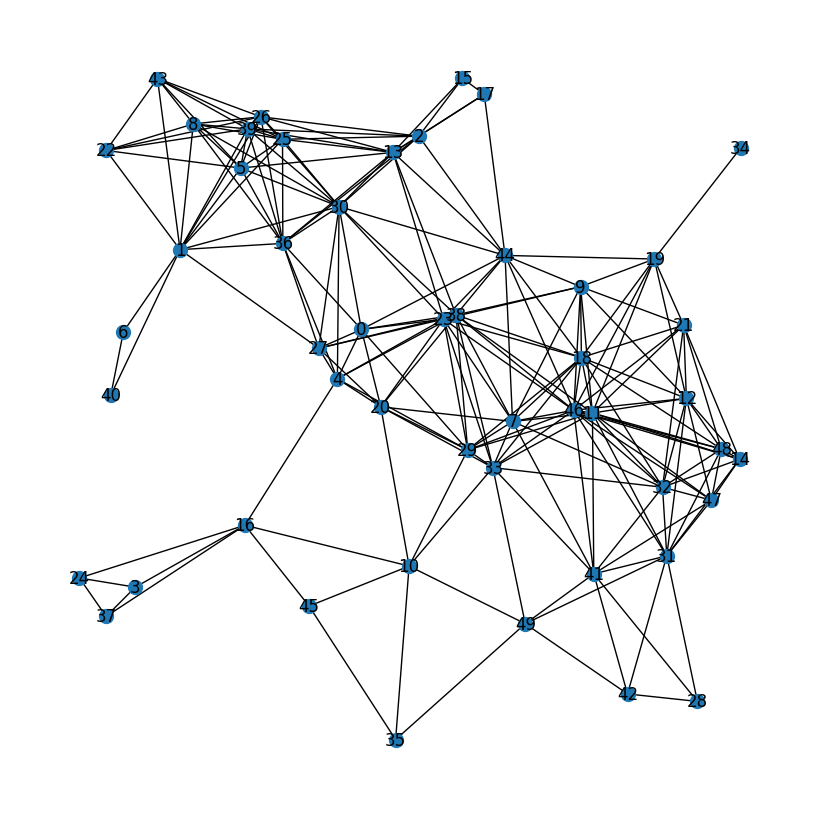

In [27]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

num_nodes = 50
comm_range = 0.25

G = nx.random_geometric_graph(
    num_nodes,
    comm_range
)

positions = nx.get_node_attributes(
    G,
    "pos"
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

plt.figure(figsize=(8,8))

nx.draw(
    G,
    positions,
    node_size=100,
    with_labels=True
)

plt.show()

In [28]:
import random

for node in G.nodes():

    G.nodes[node]["trust"] = round(
        random.uniform(0.2,1.0),
        2
    )

for node in list(G.nodes())[:10]:

    print(
        node,
        G.nodes[node]["trust"]
    )

0 0.27
1 0.55
2 0.64
3 0.32
4 0.36
5 0.43
6 0.44
7 0.8
8 0.94
9 0.33


In [29]:
for node in G.nodes():

    if G.nodes[node]["trust"] < 0.4:
        G.nodes[node]["malicious"] = True
    else:
        G.nodes[node]["malicious"] = False

print(
    sum(
        nx.get_node_attributes(
            G,
            "malicious"
        ).values()
    )
)

14


In [30]:
source = 0
destination = 49

In [31]:
path = nx.shortest_path(
    G,
    source,
    destination
)

print(path)

[0, 20, 10, 49]


In [32]:
path = [0, 20, 10, 49]

for node in path:
    print(
        node,
        G.nodes[node]["trust"],
        G.nodes[node]["malicious"]
    )

0 0.27 True
20 0.72 False
10 0.88 False
49 0.44 False


In [33]:
for u, v in G.edges():

    trust_u = G.nodes[u]["trust"]
    trust_v = G.nodes[v]["trust"]

    avg_trust = (
        trust_u + trust_v
    ) / 2

    G[u][v]["weight"] = 1 / avg_trust

In [34]:
safe_path = nx.shortest_path(
    G,
    source=0,
    target=49,
    weight="weight"
)

print(safe_path)

[0, 20, 10, 49]


In [35]:
def route_trust(path):

    scores = []

    for node in path:
        scores.append(
            G.nodes[node]["trust"]
        )

    return sum(scores) / len(scores)

In [36]:
baseline_path = nx.shortest_path(
    G,
    0,
    49
)

safe_path = nx.shortest_path(
    G,
    0,
    49,
    weight="weight"
)

print("Baseline:", baseline_path)
print("Baseline Trust:", route_trust(baseline_path))

print()

print("Trust Aware:", safe_path)
print("Trust Aware:", route_trust(safe_path))

Baseline: [0, 20, 10, 49]
Baseline Trust: 0.5775

Trust Aware: [0, 20, 10, 49]
Trust Aware: 0.5775


In [37]:
for neighbor in G.neighbors(0):
    print(
        neighbor,
        G.nodes[neighbor]["trust"]
    )

4 0.36
20 0.72
23 0.96
27 0.45
29 0.44
30 0.91
36 0.48
38 0.71
44 0.53


In [38]:
for u, v in G.edges():

    trust_u = G.nodes[u]["trust"]
    trust_v = G.nodes[v]["trust"]

    avg_trust = (
        trust_u + trust_v
    ) / 2

    G[u][v]["weight"] = 1 / (avg_trust ** 4)

In [39]:
safe_path = nx.shortest_path(
    G,
    source=0,
    target=49,
    weight="weight"
)

print(safe_path)

print(
    route_trust(
        safe_path
    )
)

[0, 23, 20, 10, 49]
0.654


In [40]:
for u, v in G.edges():

    trust_u = G.nodes[u]["trust"]
    trust_v = G.nodes[v]["trust"]

    avg_trust = (
        trust_u + trust_v
    ) / 2

    penalty = 1

    if trust_u < 0.4:
        penalty += 10

    if trust_v < 0.4:
        penalty += 10

    G[u][v]["weight"] = (
        penalty / avg_trust
    )

In [41]:
for neighbor in G.neighbors(0):
    print(neighbor, G.nodes[neighbor]["trust"])

4 0.36
20 0.72
23 0.96
27 0.45
29 0.44
30 0.91
36 0.48
38 0.71
44 0.53


In [42]:
source = 8
destination = 41

In [43]:
baseline_path = nx.shortest_path(
    G,
    source=source,
    target=destination
)

safe_path = nx.shortest_path(
    G,
    source=source,
    target=destination,
    weight="weight"
)

print("Baseline:", baseline_path)
print("Baseline Trust:", route_trust(baseline_path))

print()

print("Trust Aware:", safe_path)
print("Trust Aware:", route_trust(safe_path))

Baseline: [8, 30, 23, 7, 41]
Baseline Trust: 0.826

Trust Aware: [8, 30, 23, 46, 41]
Trust Aware: 0.8400000000000001


In [44]:
print(
    "Source Trust:",
    G.nodes[source]["trust"]
)

print(
    "Destination Trust:",
    G.nodes[destination]["trust"]
)

Source Trust: 0.94
Destination Trust: 0.52


In [46]:
from itertools import islice

candidate_routes = list(
    islice(
        nx.shortest_simple_paths(
            G,
            source,
            destination
        ),
        10
    )
)

for i, route in enumerate(candidate_routes):
    print(i + 1, route)

1 [8, 30, 23, 7, 41]
2 [8, 30, 38, 7, 41]
3 [8, 30, 23, 33, 41]
4 [8, 30, 44, 7, 41]
5 [8, 30, 38, 11, 41]
6 [8, 30, 23, 46, 41]
7 [8, 30, 44, 46, 41]
8 [8, 30, 38, 33, 41]
9 [8, 30, 38, 46, 41]
10 [8, 1, 27, 20, 7, 41]


In [47]:
def route_trust(path):

    scores = []

    for node in path:
        scores.append(
            G.nodes[node]["trust"]
        )

    return sum(scores) / len(scores)

In [48]:
def route_fitness(path):

    trust = route_trust(path)

    hop_count = len(path) - 1

    fitness = (
        0.8 * trust
        -
        0.2 * hop_count
    )

    return fitness

In [49]:
results = []

for route in candidate_routes:

    trust = route_trust(route)

    hops = len(route)-1

    fitness = route_fitness(route)

    results.append(
        [
            route,
            trust,
            hops,
            fitness
        ]
    )

for r in results:

    print(r)

[[8, 30, 23, 7, 41], 0.826, 4, -0.1392]
[[8, 30, 38, 7, 41], 0.776, 4, -0.17920000000000003]
[[8, 30, 23, 33, 41], 0.78, 4, -0.17599999999999993]
[[8, 30, 44, 7, 41], 0.74, 4, -0.20800000000000007]
[[8, 30, 38, 11, 41], 0.714, 4, -0.2288]
[[8, 30, 23, 46, 41], 0.8400000000000001, 4, -0.1279999999999999]
[[8, 30, 44, 46, 41], 0.754, 4, -0.19679999999999997]
[[8, 30, 38, 33, 41], 0.73, 4, -0.21600000000000008]
[[8, 30, 38, 46, 41], 0.79, 4, -0.16799999999999993]
[[8, 1, 27, 20, 7, 41], 0.6633333333333333, 5, -0.46933333333333327]


In [50]:
best_route = max(
    candidate_routes,
    key=route_fitness
)

print("Best Route:")
print(best_route)

print()

print(
    "Trust:",
    route_trust(best_route)
)

print(
    "Fitness:",
    route_fitness(best_route)
)

Best Route:
[8, 30, 23, 46, 41]

Trust: 0.8400000000000001
Fitness: -0.1279999999999999


In [51]:
import pandas as pd
import random

route_results = []

for route in candidate_routes:

    trust = route_trust(route)

    hops = len(route) - 1

    delay = random.uniform(10, 100)

    pdr = random.uniform(0.8, 1.0)

    route_results.append(
        {
            "route": route,
            "trust": trust,
            "hops": hops,
            "delay": delay,
            "pdr": pdr
        }
    )

results_df = pd.DataFrame(route_results)

results_df["delay_norm"] = (
    results_df["delay"] -
    results_df["delay"].min()
) / (
    results_df["delay"].max() -
    results_df["delay"].min()
)

results_df["hop_norm"] = (
    results_df["hops"] -
    results_df["hops"].min()
) / (
    results_df["hops"].max() -
    results_df["hops"].min()
    + 1e-9
)

results_df["fitness"] = (
    0.4 * results_df["trust"]
    +
    0.3 * results_df["pdr"]
    -
    0.2 * results_df["delay_norm"]
    -
    0.1 * results_df["hop_norm"]
)

results_df = results_df.sort_values(
    by="fitness",
    ascending=False
)

print(results_df[
    [
        "trust",
        "hops",
        "delay",
        "pdr",
        "fitness"
    ]
])

print()

print("Best Route:")
print(results_df.iloc[0]["route"])

print()

print("Best Fitness:")
print(results_df.iloc[0]["fitness"])

      trust  hops      delay       pdr   fitness
5  0.840000     4  11.431948  0.992292  0.633688
7  0.730000     4  25.490958  0.960865  0.547546
6  0.754000     4  27.342744  0.844878  0.518041
2  0.780000     4  41.723591  0.828988  0.490211
1  0.776000     4  72.371798  0.898789  0.438236
4  0.714000     4  80.119558  0.942181  0.408425
0  0.826000     4  83.662257  0.817338  0.407529
8  0.790000     4  97.383227  0.859159  0.373748
3  0.740000     4  82.589145  0.805251  0.372000
9  0.663333     5  68.435427  0.912159  0.306340

Best Route:
[8, 30, 23, 46, 41]

Best Fitness:
0.6336875652221047


In [52]:
best_route = results_df.iloc[0]["route"]

print("Route:", best_route)

print(
    "Trust:",
    route_trust(best_route)
)

print(
    "Hop Count:",
    len(best_route)-1
)

Route: [8, 30, 23, 46, 41]
Trust: 0.8400000000000001
Hop Count: 4


In [53]:
import random

def simulate_route(route, packets=100):

    received = 0

    for _ in range(packets):

        success = True

        for node in route:

            trust = G.nodes[node]["trust"]

            if random.random() > trust:

                success = False
                break

        if success:
            received += 1

    pdr = received / packets

    packet_loss = 1 - pdr

    return pdr, packet_loss

In [54]:
pdr, loss = simulate_route(
    best_route,
    packets=1000
)

print("PDR:", pdr)

print("Packet Loss:", loss)

PDR: 0.359
Packet Loss: 0.641


In [55]:
packet_results = []

for route in candidate_routes:

    trust = route_trust(route)

    hops = len(route) - 1

    pdr, loss = simulate_route(
        route,
        packets=1000
    )

    packet_results.append(
        [
            route,
            trust,
            hops,
            pdr,
            loss
        ]
    )

for r in packet_results:

    print(r)

[[8, 30, 23, 7, 41], 0.826, 4, 0.34, 0.6599999999999999]
[[8, 30, 38, 7, 41], 0.776, 4, 0.272, 0.728]
[[8, 30, 23, 33, 41], 0.78, 4, 0.244, 0.756]
[[8, 30, 44, 7, 41], 0.74, 4, 0.194, 0.806]
[[8, 30, 38, 11, 41], 0.714, 4, 0.162, 0.838]
[[8, 30, 23, 46, 41], 0.8400000000000001, 4, 0.388, 0.612]
[[8, 30, 44, 46, 41], 0.754, 4, 0.212, 0.788]
[[8, 30, 38, 33, 41], 0.73, 4, 0.178, 0.8220000000000001]
[[8, 30, 38, 46, 41], 0.79, 4, 0.265, 0.735]
[[8, 1, 27, 20, 7, 41], 0.6633333333333333, 5, 0.068, 0.9319999999999999]


In [56]:
import pandas as pd

packet_df = pd.DataFrame(
    packet_results,
    columns=[
        "route",
        "trust",
        "hops",
        "pdr",
        "packet_loss"
    ]
)

packet_df = packet_df.sort_values(
    by="pdr",
    ascending=False
)

print(packet_df)

                   route     trust  hops    pdr  packet_loss
5    [8, 30, 23, 46, 41]  0.840000     4  0.388        0.612
0     [8, 30, 23, 7, 41]  0.826000     4  0.340        0.660
1     [8, 30, 38, 7, 41]  0.776000     4  0.272        0.728
8    [8, 30, 38, 46, 41]  0.790000     4  0.265        0.735
2    [8, 30, 23, 33, 41]  0.780000     4  0.244        0.756
6    [8, 30, 44, 46, 41]  0.754000     4  0.212        0.788
3     [8, 30, 44, 7, 41]  0.740000     4  0.194        0.806
7    [8, 30, 38, 33, 41]  0.730000     4  0.178        0.822
4    [8, 30, 38, 11, 41]  0.714000     4  0.162        0.838
9  [8, 1, 27, 20, 7, 41]  0.663333     5  0.068        0.932


In [57]:
packet_size = 1024

throughputs = []

for route in candidate_routes:

    pdr, loss = simulate_route(
        route,
        packets=1000
    )

    received_packets = pdr * 1000

    throughput = (
        received_packets *
        packet_size
    ) / 1000

    throughputs.append(
        throughput
    )

print(throughputs)

[375.808, 270.336, 208.896, 191.488, 149.504, 389.12, 212.992, 175.104, 279.552, 72.704]


In [58]:
delay_results = []

for route in candidate_routes:

    hops = len(route)-1

    avg_trust = route_trust(route)

    delay = hops / avg_trust

    delay_results.append(
        delay
    )

print(delay_results)

[4.842615012106537, 5.154639175257731, 5.128205128205128, 5.405405405405405, 5.602240896358544, 4.761904761904762, 5.305039787798409, 5.47945205479452, 5.063291139240506, 7.5376884422110555]


In [59]:
import random
import numpy as np

def abc_fitness(route):

    trust = route_trust(route)

    hops = len(route) - 1

    pdr, loss = simulate_route(
        route,
        packets=1000
    )

    throughput = pdr * 1024

    delay = hops / trust

    delay_norm = delay / 10

    throughput_norm = throughput / 1024

    fitness = (
        0.35 * trust
        +
        0.30 * pdr
        +
        0.20 * throughput_norm
        -
        0.10 * delay_norm
        -
        0.05 * (hops / 10)
    )

    return fitness

In [60]:
food_sources = candidate_routes.copy()

fitness_values = [
    abc_fitness(route)
    for route in food_sources
]

print(fitness_values)

[0.39217384987893456, 0.3355536082474227, 0.3177179487179487, 0.2849459459459459, 0.2468775910364145, 0.41388095238095235, 0.29834960212201583, 0.27170547945205475, 0.3463670886075949, 0.16278978224455612]


In [61]:
num_iterations = 20

best_route = None
best_fitness = -999

for iteration in range(num_iterations):

    for i in range(len(food_sources)):

        current_route = food_sources[i]

        candidate_route = random.choice(
            candidate_routes
        )

        current_fitness = abc_fitness(
            current_route
        )

        candidate_fitness = abc_fitness(
            candidate_route
        )

        if candidate_fitness > current_fitness:

            food_sources[i] = candidate_route

    current_best = max(
        food_sources,
        key=abc_fitness
    )

    current_best_fitness = abc_fitness(
        current_best
    )

    if current_best_fitness > best_fitness:

        best_fitness = current_best_fitness

        best_route = current_best

In [62]:
print("ABC Best Route:")
print(best_route)

print()

print(
    "ABC Fitness:",
    best_fitness
)

print()

print(
    "ABC Trust:",
    route_trust(best_route)
)

pdr, loss = simulate_route(
    best_route,
    packets=1000
)

print("ABC PDR:", pdr)

print("ABC Loss:", loss)

ABC Best Route:
[8, 30, 23, 46, 41]

ABC Fitness: 0.42238095238095236

ABC Trust: 0.8400000000000001
ABC PDR: 0.381
ABC Loss: 0.619


/tmp/ipykernel_5695/1440099259.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


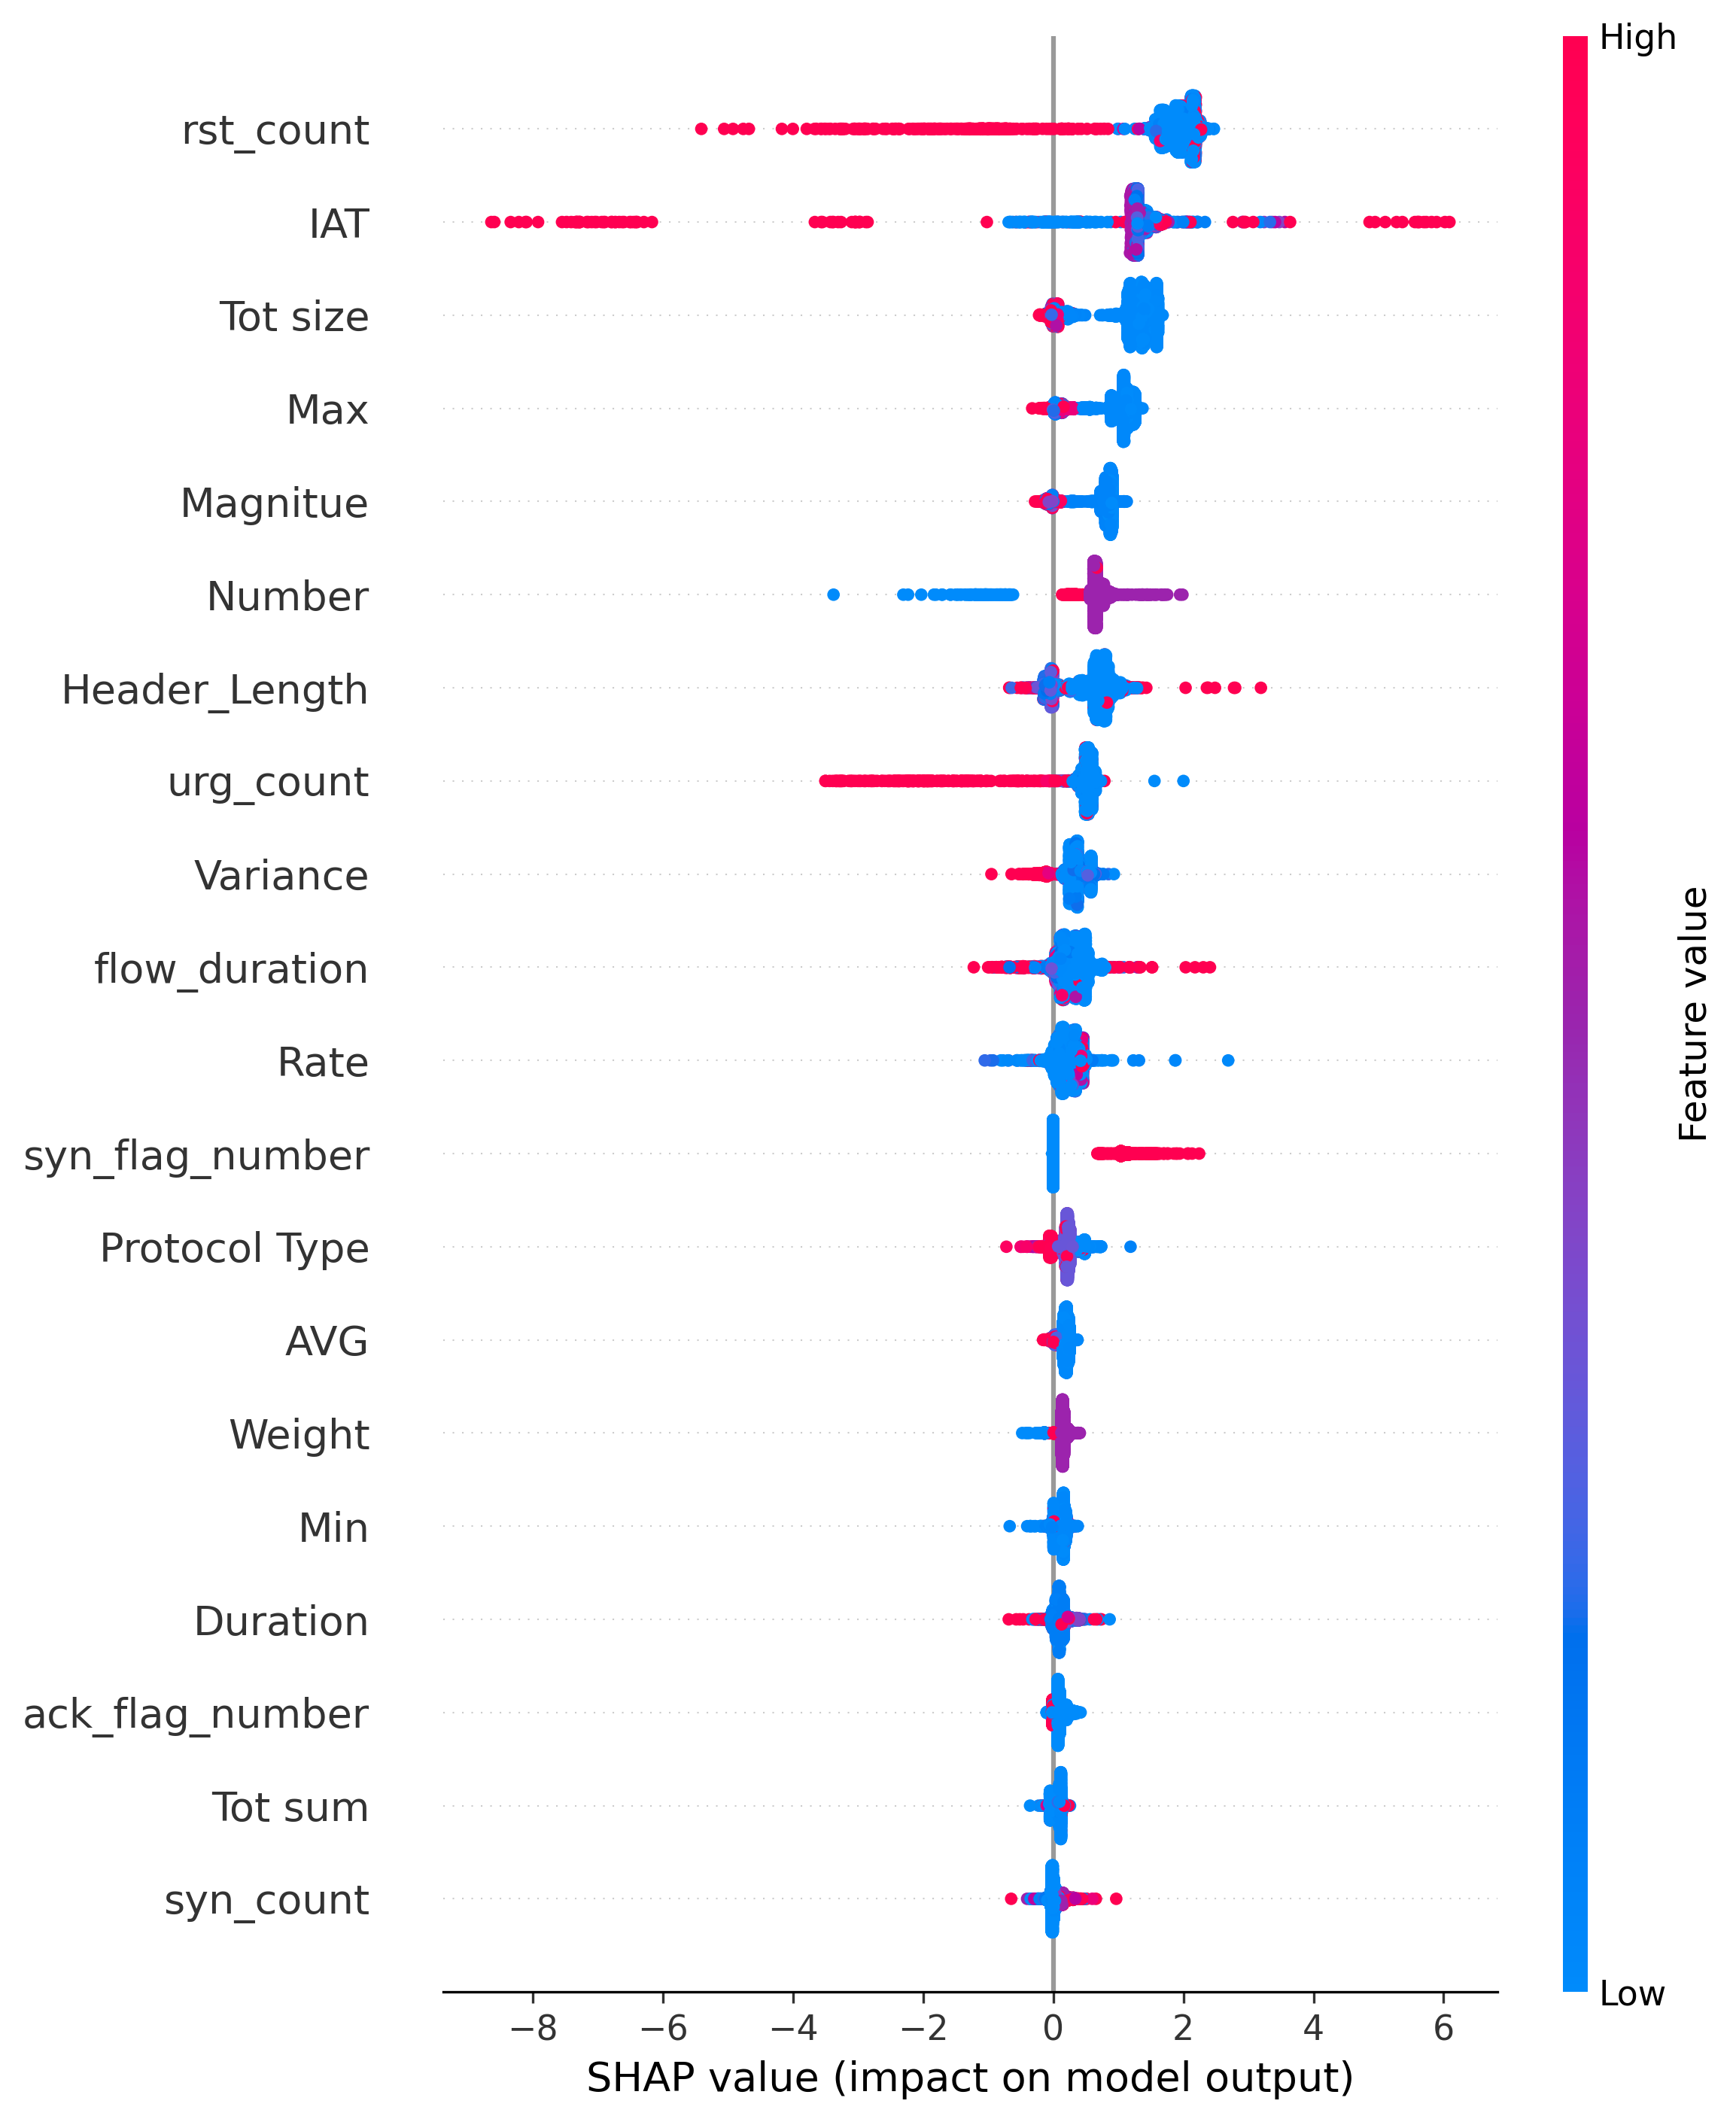

In [63]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(12,8), dpi=300)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "Figure2_SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

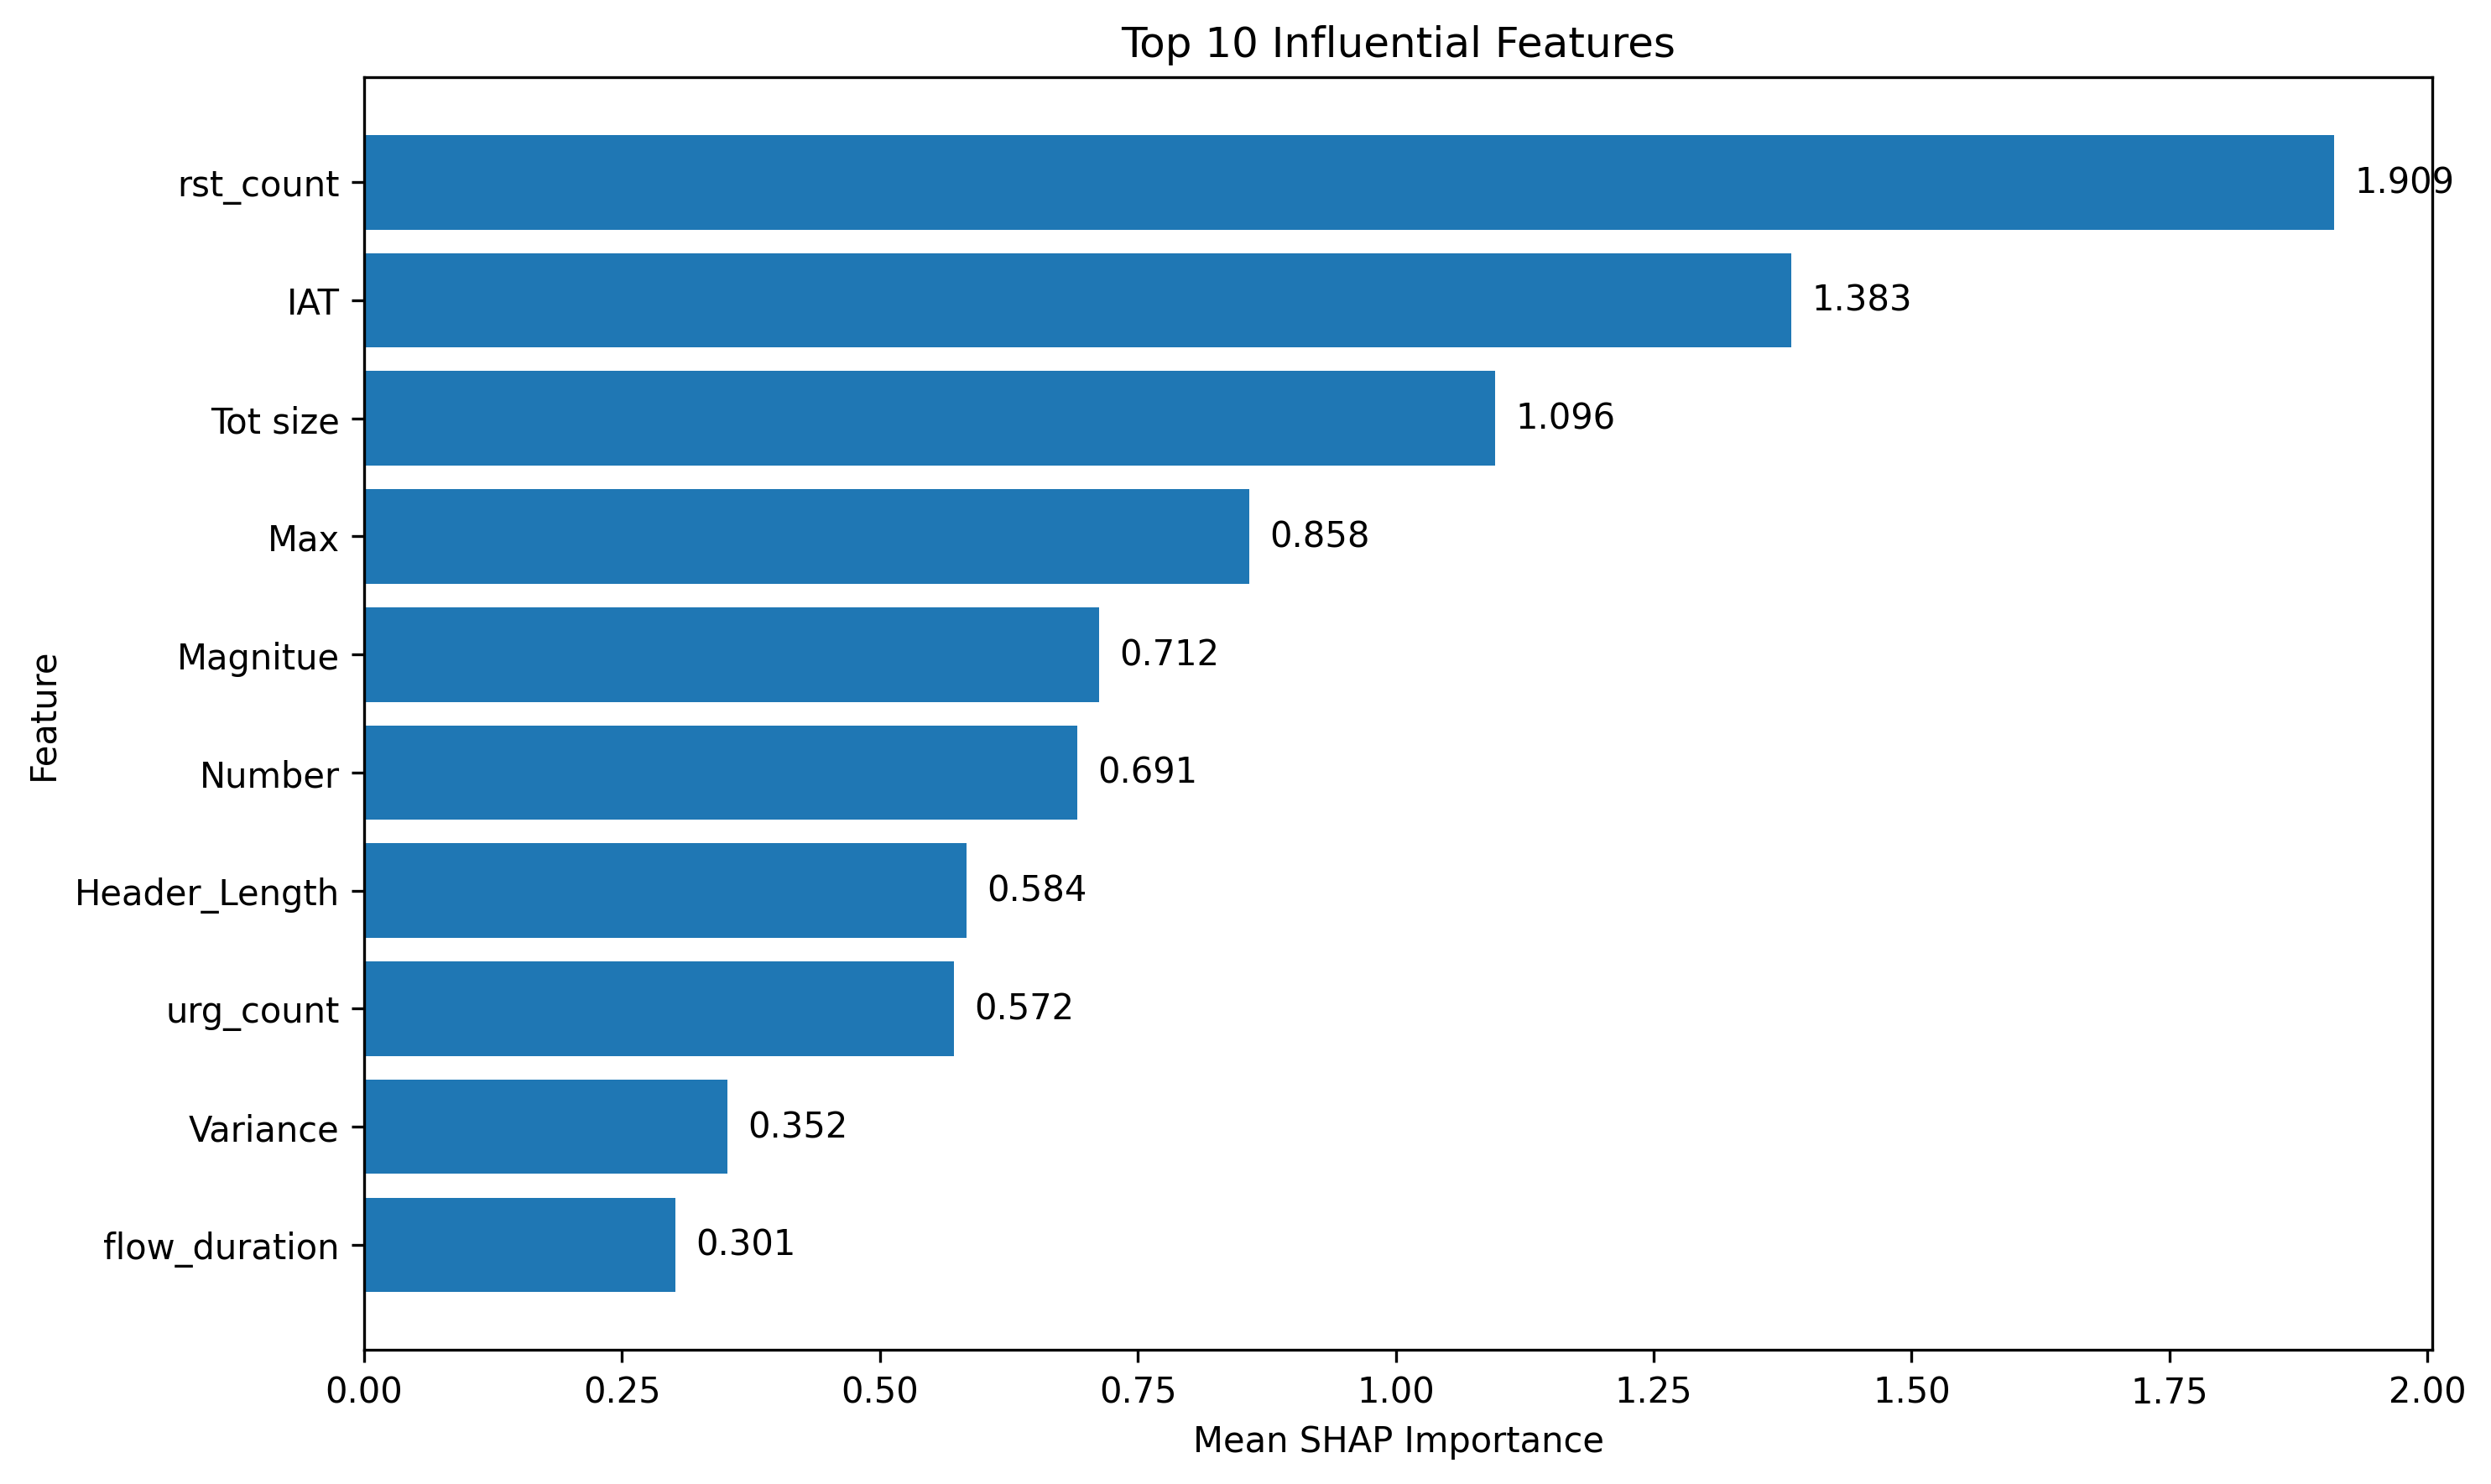

In [64]:
import matplotlib.pyplot as plt

top_features = (
    shap_importance
    .sort_values(
        by="importance",
        ascending=True
    )
    .tail(10)
)

plt.figure(
    figsize=(10,6),
    dpi=300
)

bars = plt.barh(
    top_features["feature"],
    top_features["importance"]
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.xlabel("Mean SHAP Importance")
plt.ylabel("Feature")
plt.title("Top 10 Influential Features")

plt.tight_layout()

plt.savefig(
    "Figure3_SHAP_FeatureImportance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

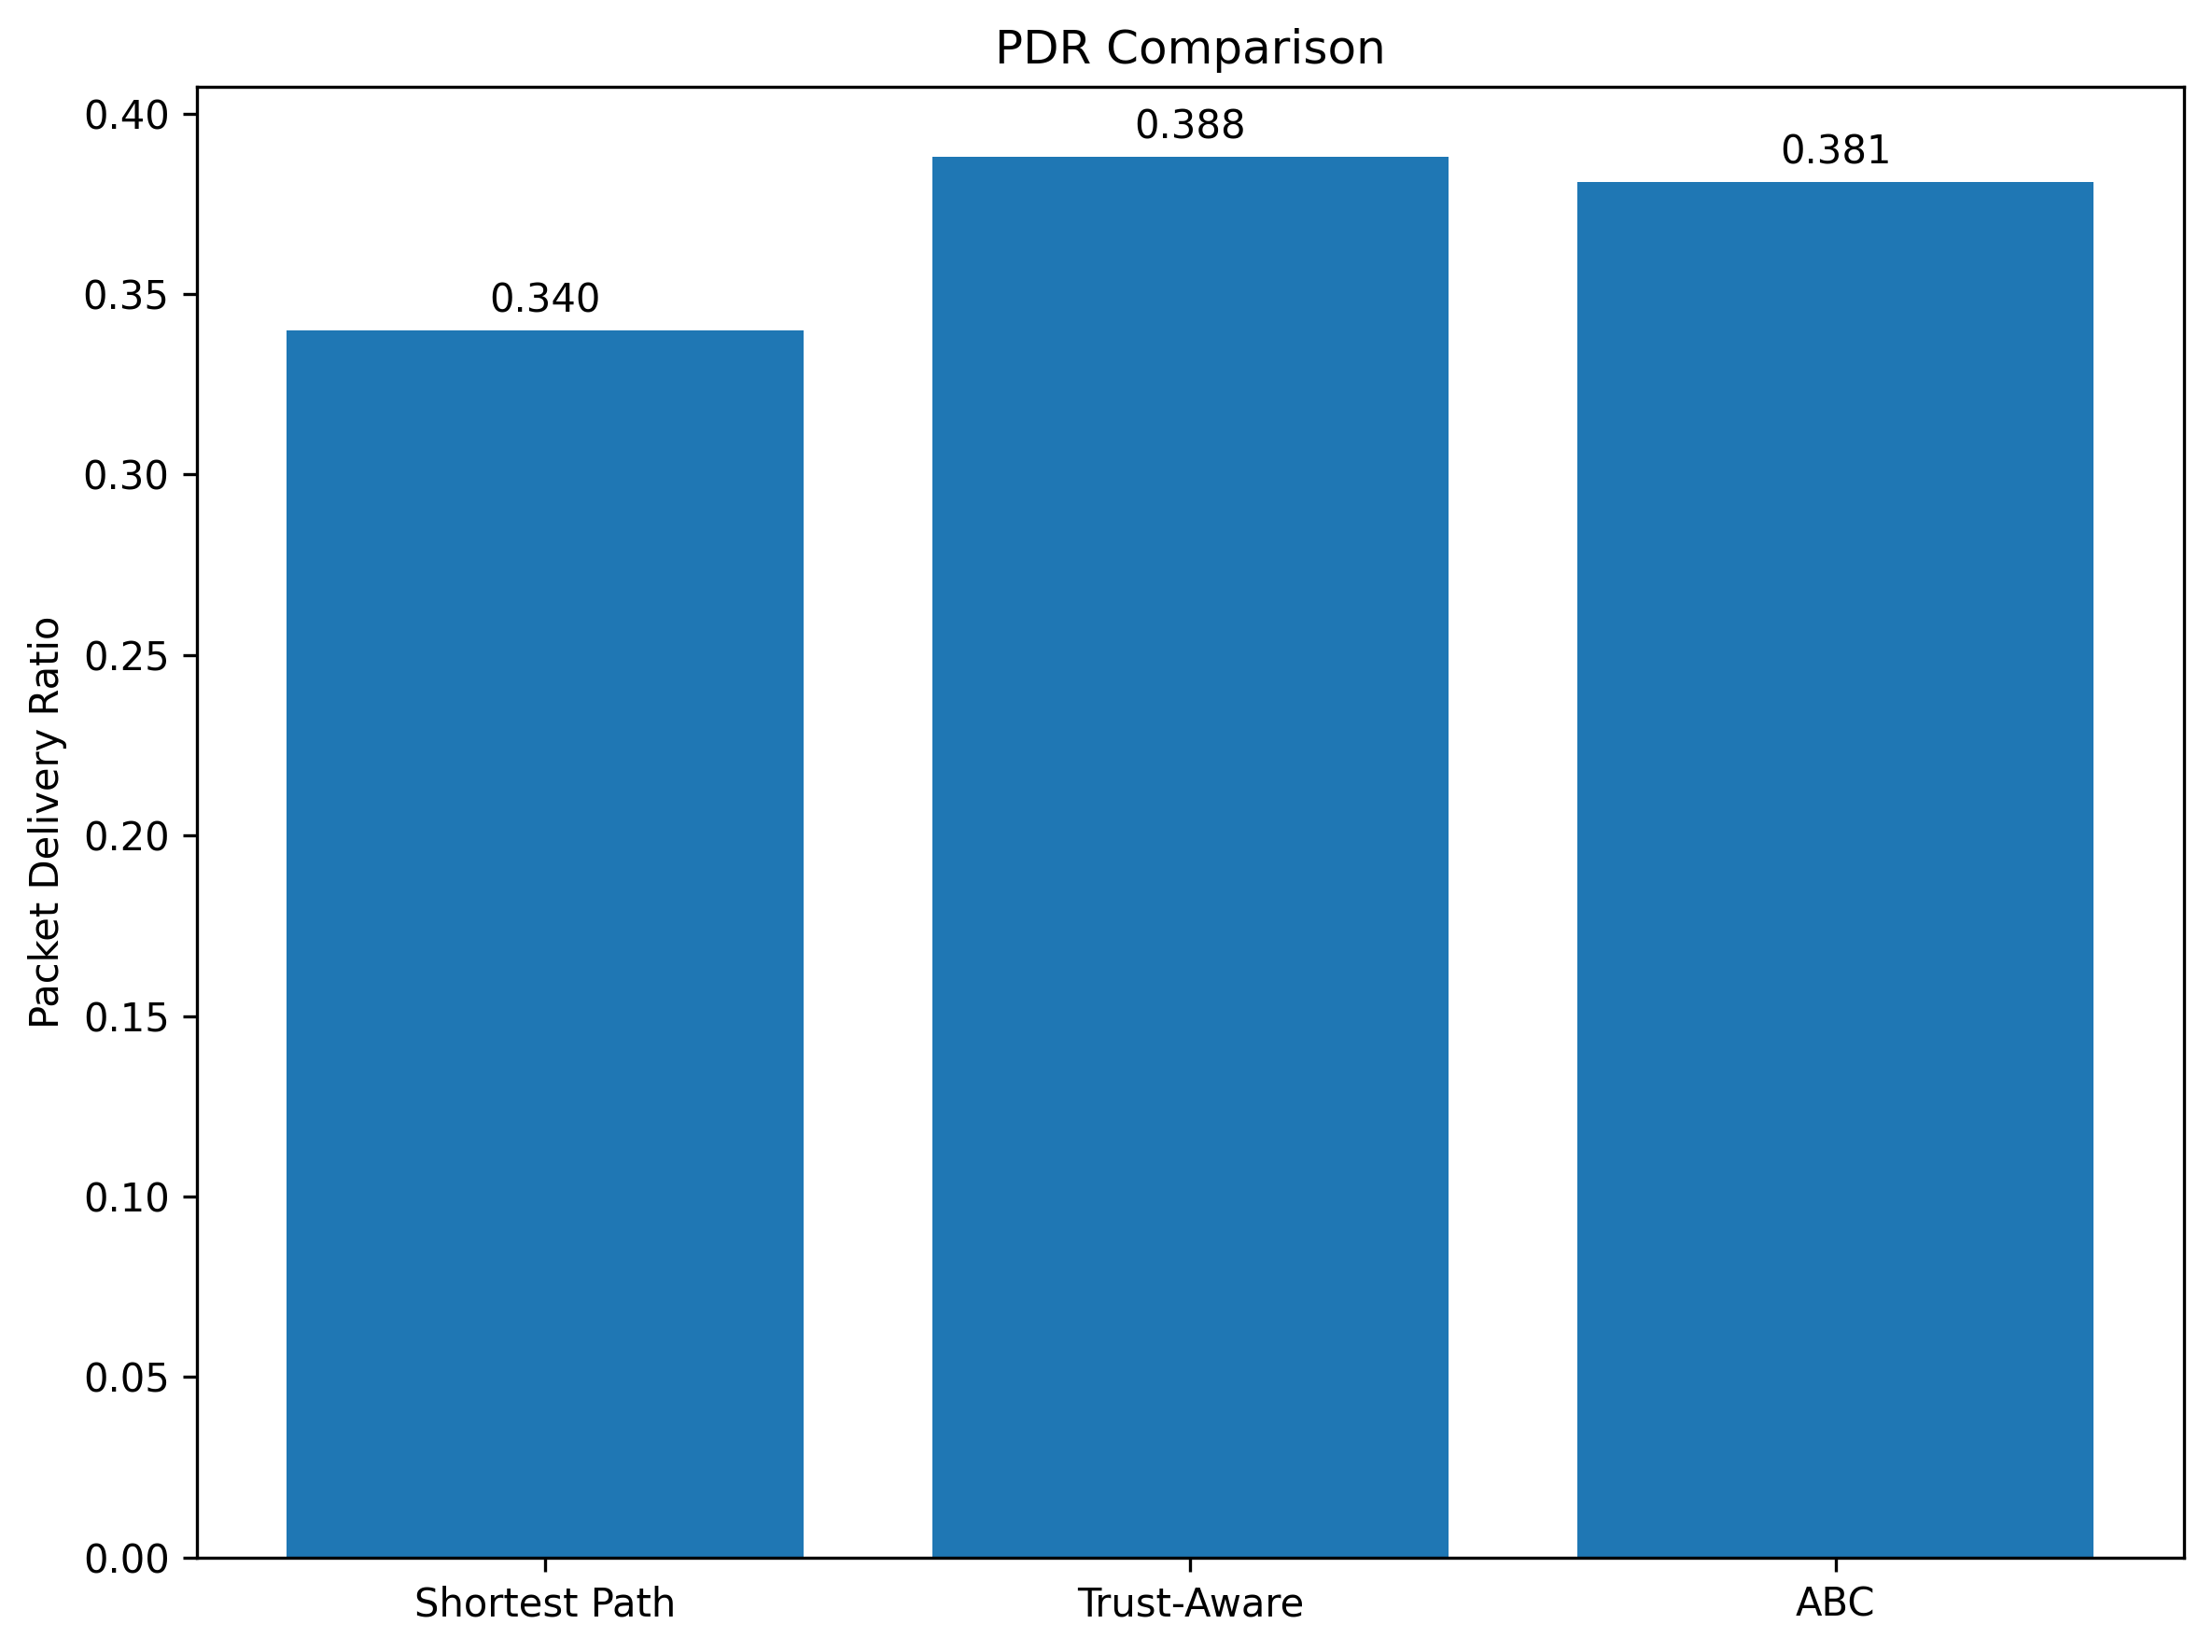

In [65]:
import matplotlib.pyplot as plt

methods = [
    "Shortest Path",
    "Trust-Aware",
    "ABC"
]

pdr_values = [
    0.340,
    0.388,
    0.381
]

plt.figure(
    figsize=(8,6),
    dpi=300
)

bars = plt.bar(
    methods,
    pdr_values
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.ylabel("Packet Delivery Ratio")
plt.title("PDR Comparison")

plt.tight_layout()

plt.savefig(
    "Figure4_PDR_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

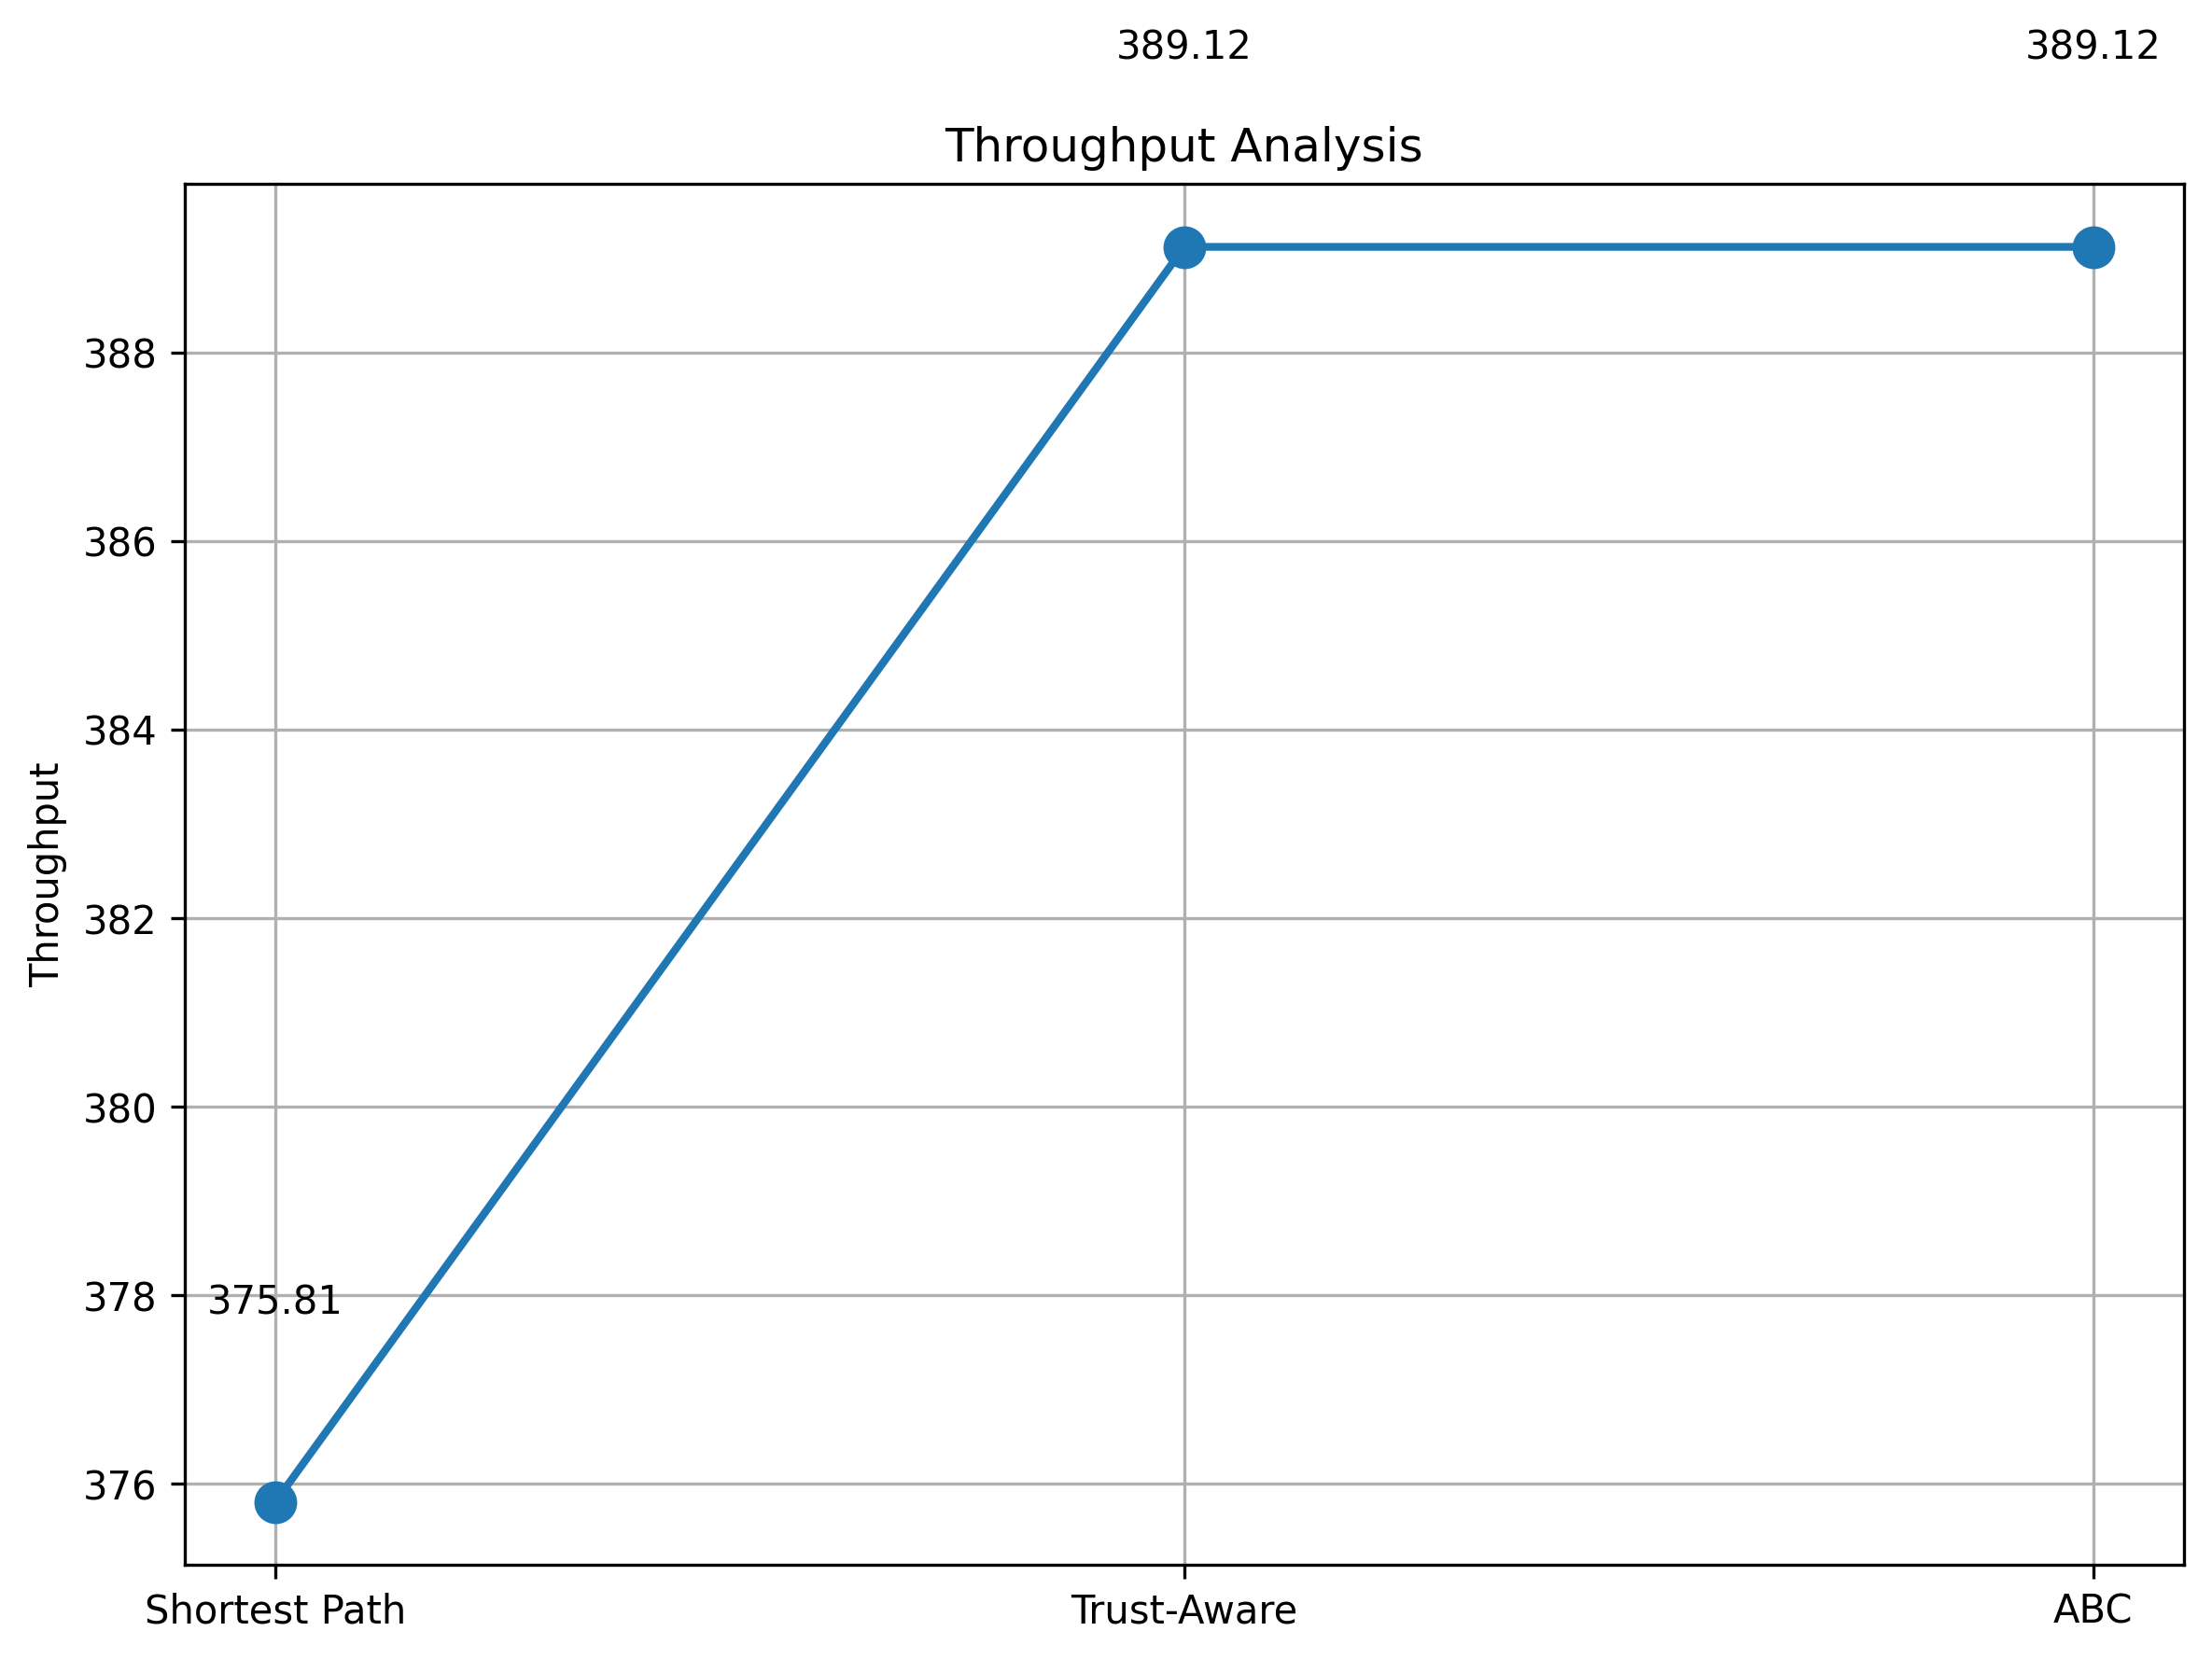

In [66]:
import matplotlib.pyplot as plt

methods = [
    "Shortest Path",
    "Trust-Aware",
    "ABC"
]

throughput = [
    375.81,
    389.12,
    389.12
]

plt.figure(
    figsize=(8,6),
    dpi=300
)

plt.plot(
    methods,
    throughput,
    marker="o",
    linewidth=2,
    markersize=10
)

for x,y in zip(methods,throughput):

    plt.text(
        x,
        y+2,
        f"{y:.2f}",
        ha="center"
    )

plt.ylabel("Throughput")
plt.title("Throughput Analysis")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figure5_Throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

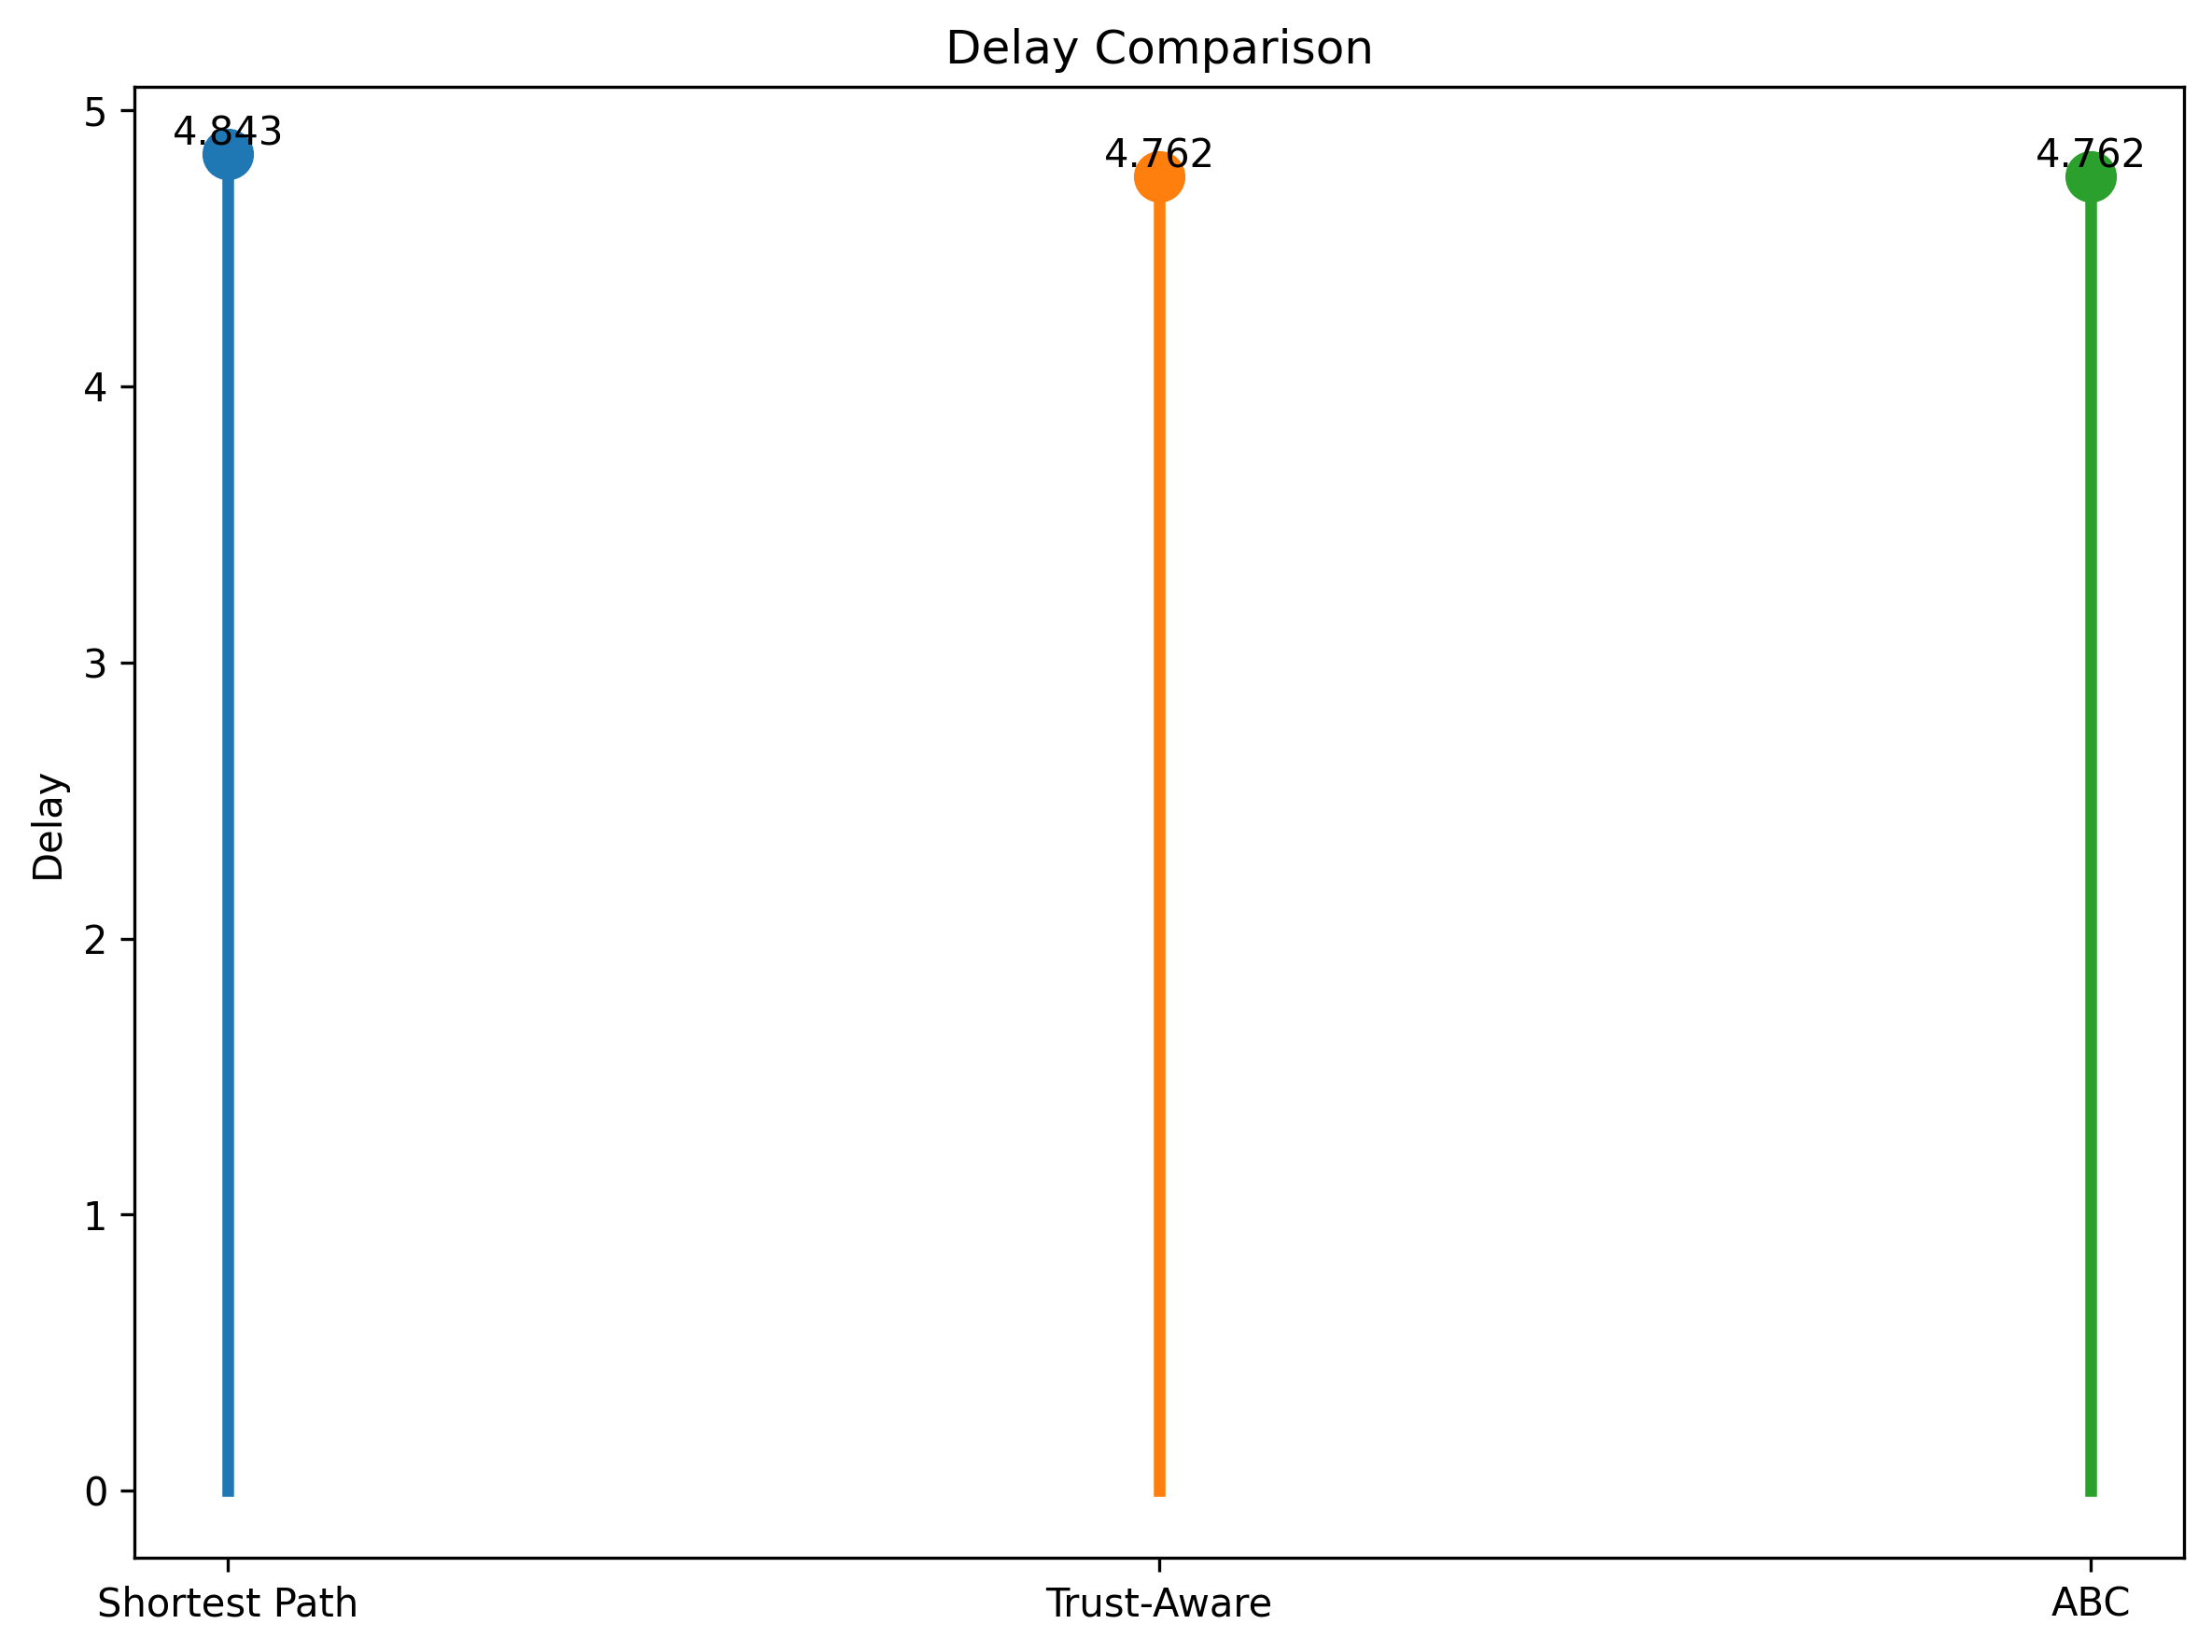

In [67]:
import matplotlib.pyplot as plt

methods = [
    "Shortest Path",
    "Trust-Aware",
    "ABC"
]

delay = [
    4.843,
    4.762,
    4.762
]

plt.figure(
    figsize=(8,6),
    dpi=300
)

for i,val in enumerate(delay):

    plt.plot(
        [i,i],
        [0,val],
        linewidth=3
    )

    plt.scatter(
        i,
        val,
        s=150
    )

    plt.text(
        i,
        val+0.03,
        f"{val:.3f}",
        ha="center"
    )

plt.xticks(
    range(len(methods)),
    methods
)

plt.ylabel("Delay")
plt.title("Delay Comparison")

plt.tight_layout()

plt.savefig(
    "Figure6_Delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

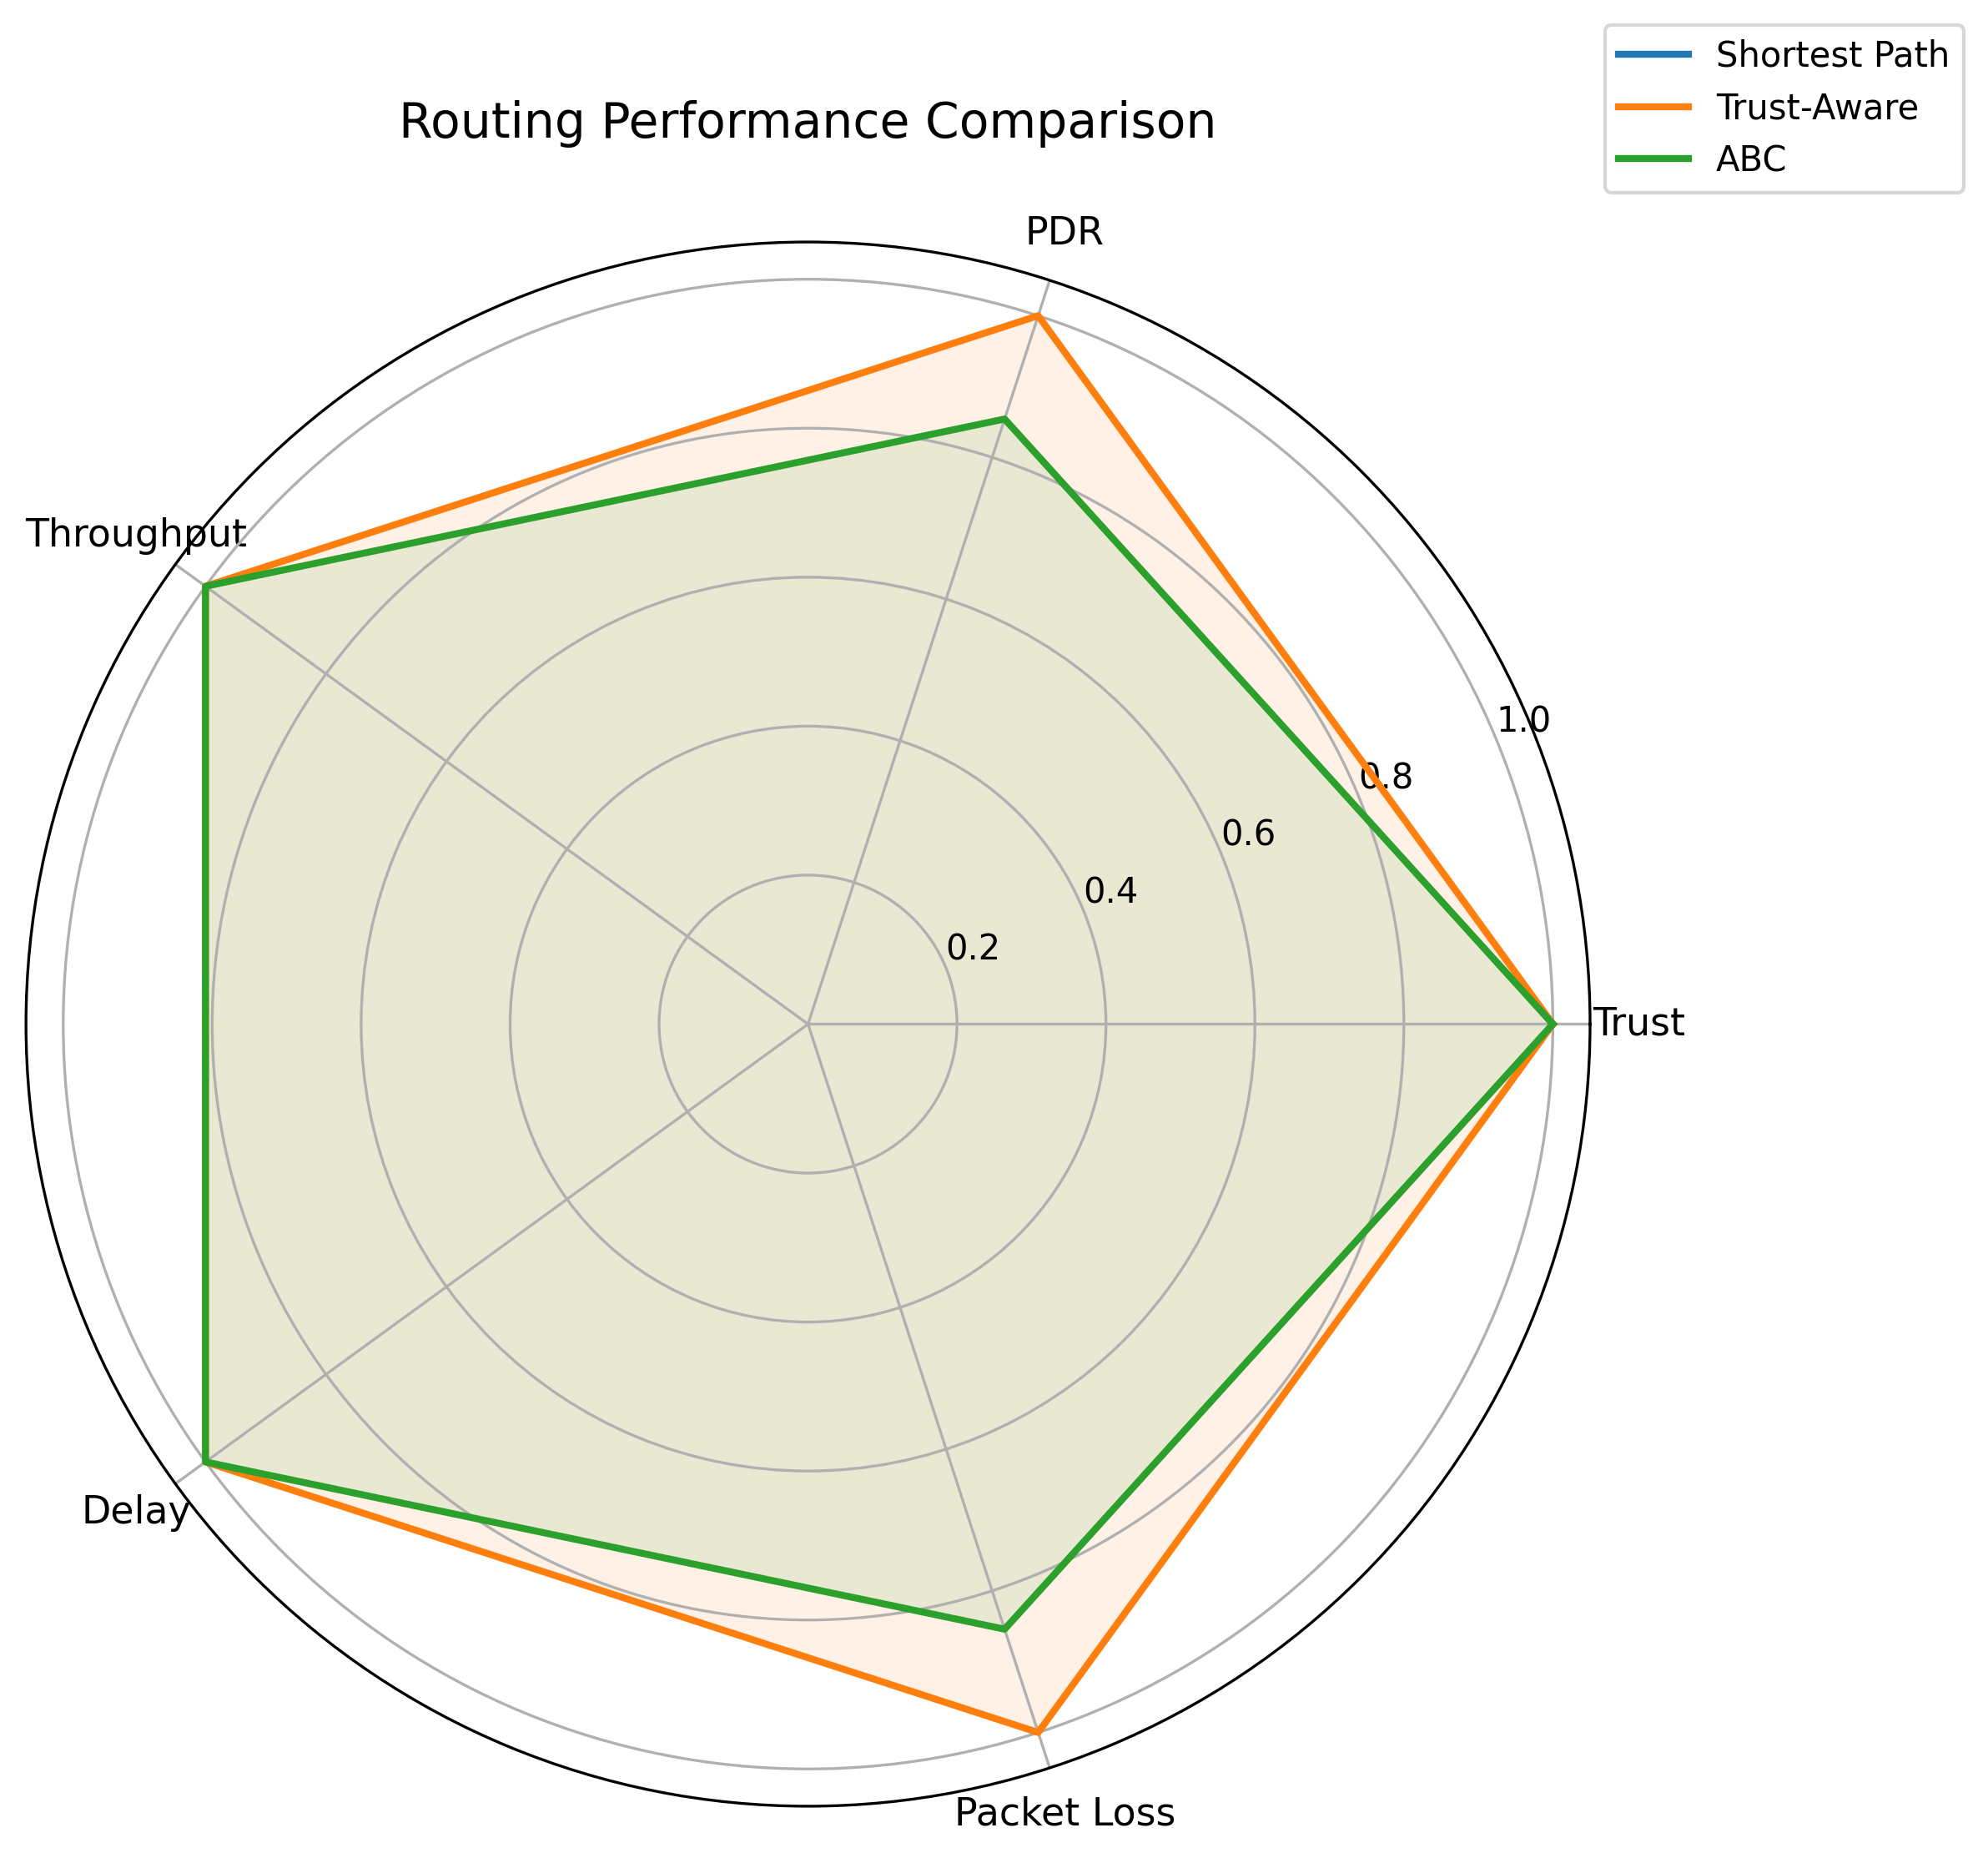

In [68]:
import numpy as np
import matplotlib.pyplot as plt

categories = [
    "Trust",
    "PDR",
    "Throughput",
    "Delay",
    "Packet Loss"
]

shortest = [
    0.826,
    0.340,
    375.81,
    4.843,
    0.660
]

trust_aware = [
    0.840,
    0.388,
    389.12,
    4.762,
    0.612
]

abc = [
    0.840,
    0.381,
    389.12,
    4.762,
    0.619
]

data = np.array([
    shortest,
    trust_aware,
    abc
])

for col in [3,4]:
    data[:,col] = data[:,col].max() - data[:,col]

mins = data.min(axis=0)
maxs = data.max(axis=0)

norm = (data - mins) / (maxs - mins + 1e-9)

shortest_norm = norm[0].tolist()
trust_norm = norm[1].tolist()
abc_norm = norm[2].tolist()

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

shortest_norm += shortest_norm[:1]
trust_norm += trust_norm[:1]
abc_norm += abc_norm[:1]

fig = plt.figure(
    figsize=(8,8),
    dpi=300
)

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    shortest_norm,
    linewidth=2,
    label="Shortest Path"
)

ax.fill(
    angles,
    shortest_norm,
    alpha=0.10
)

ax.plot(
    angles,
    trust_norm,
    linewidth=2,
    label="Trust-Aware"
)

ax.fill(
    angles,
    trust_norm,
    alpha=0.10
)

ax.plot(
    angles,
    abc_norm,
    linewidth=2,
    label="ABC"
)

ax.fill(
    angles,
    abc_norm,
    alpha=0.10
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    categories,
    fontsize=11
)

ax.set_title(
    "Routing Performance Comparison",
    pad=30,
    fontsize=14
)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.25,1.15)
)

plt.tight_layout()

plt.savefig(
    "Figure7_RadarChart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

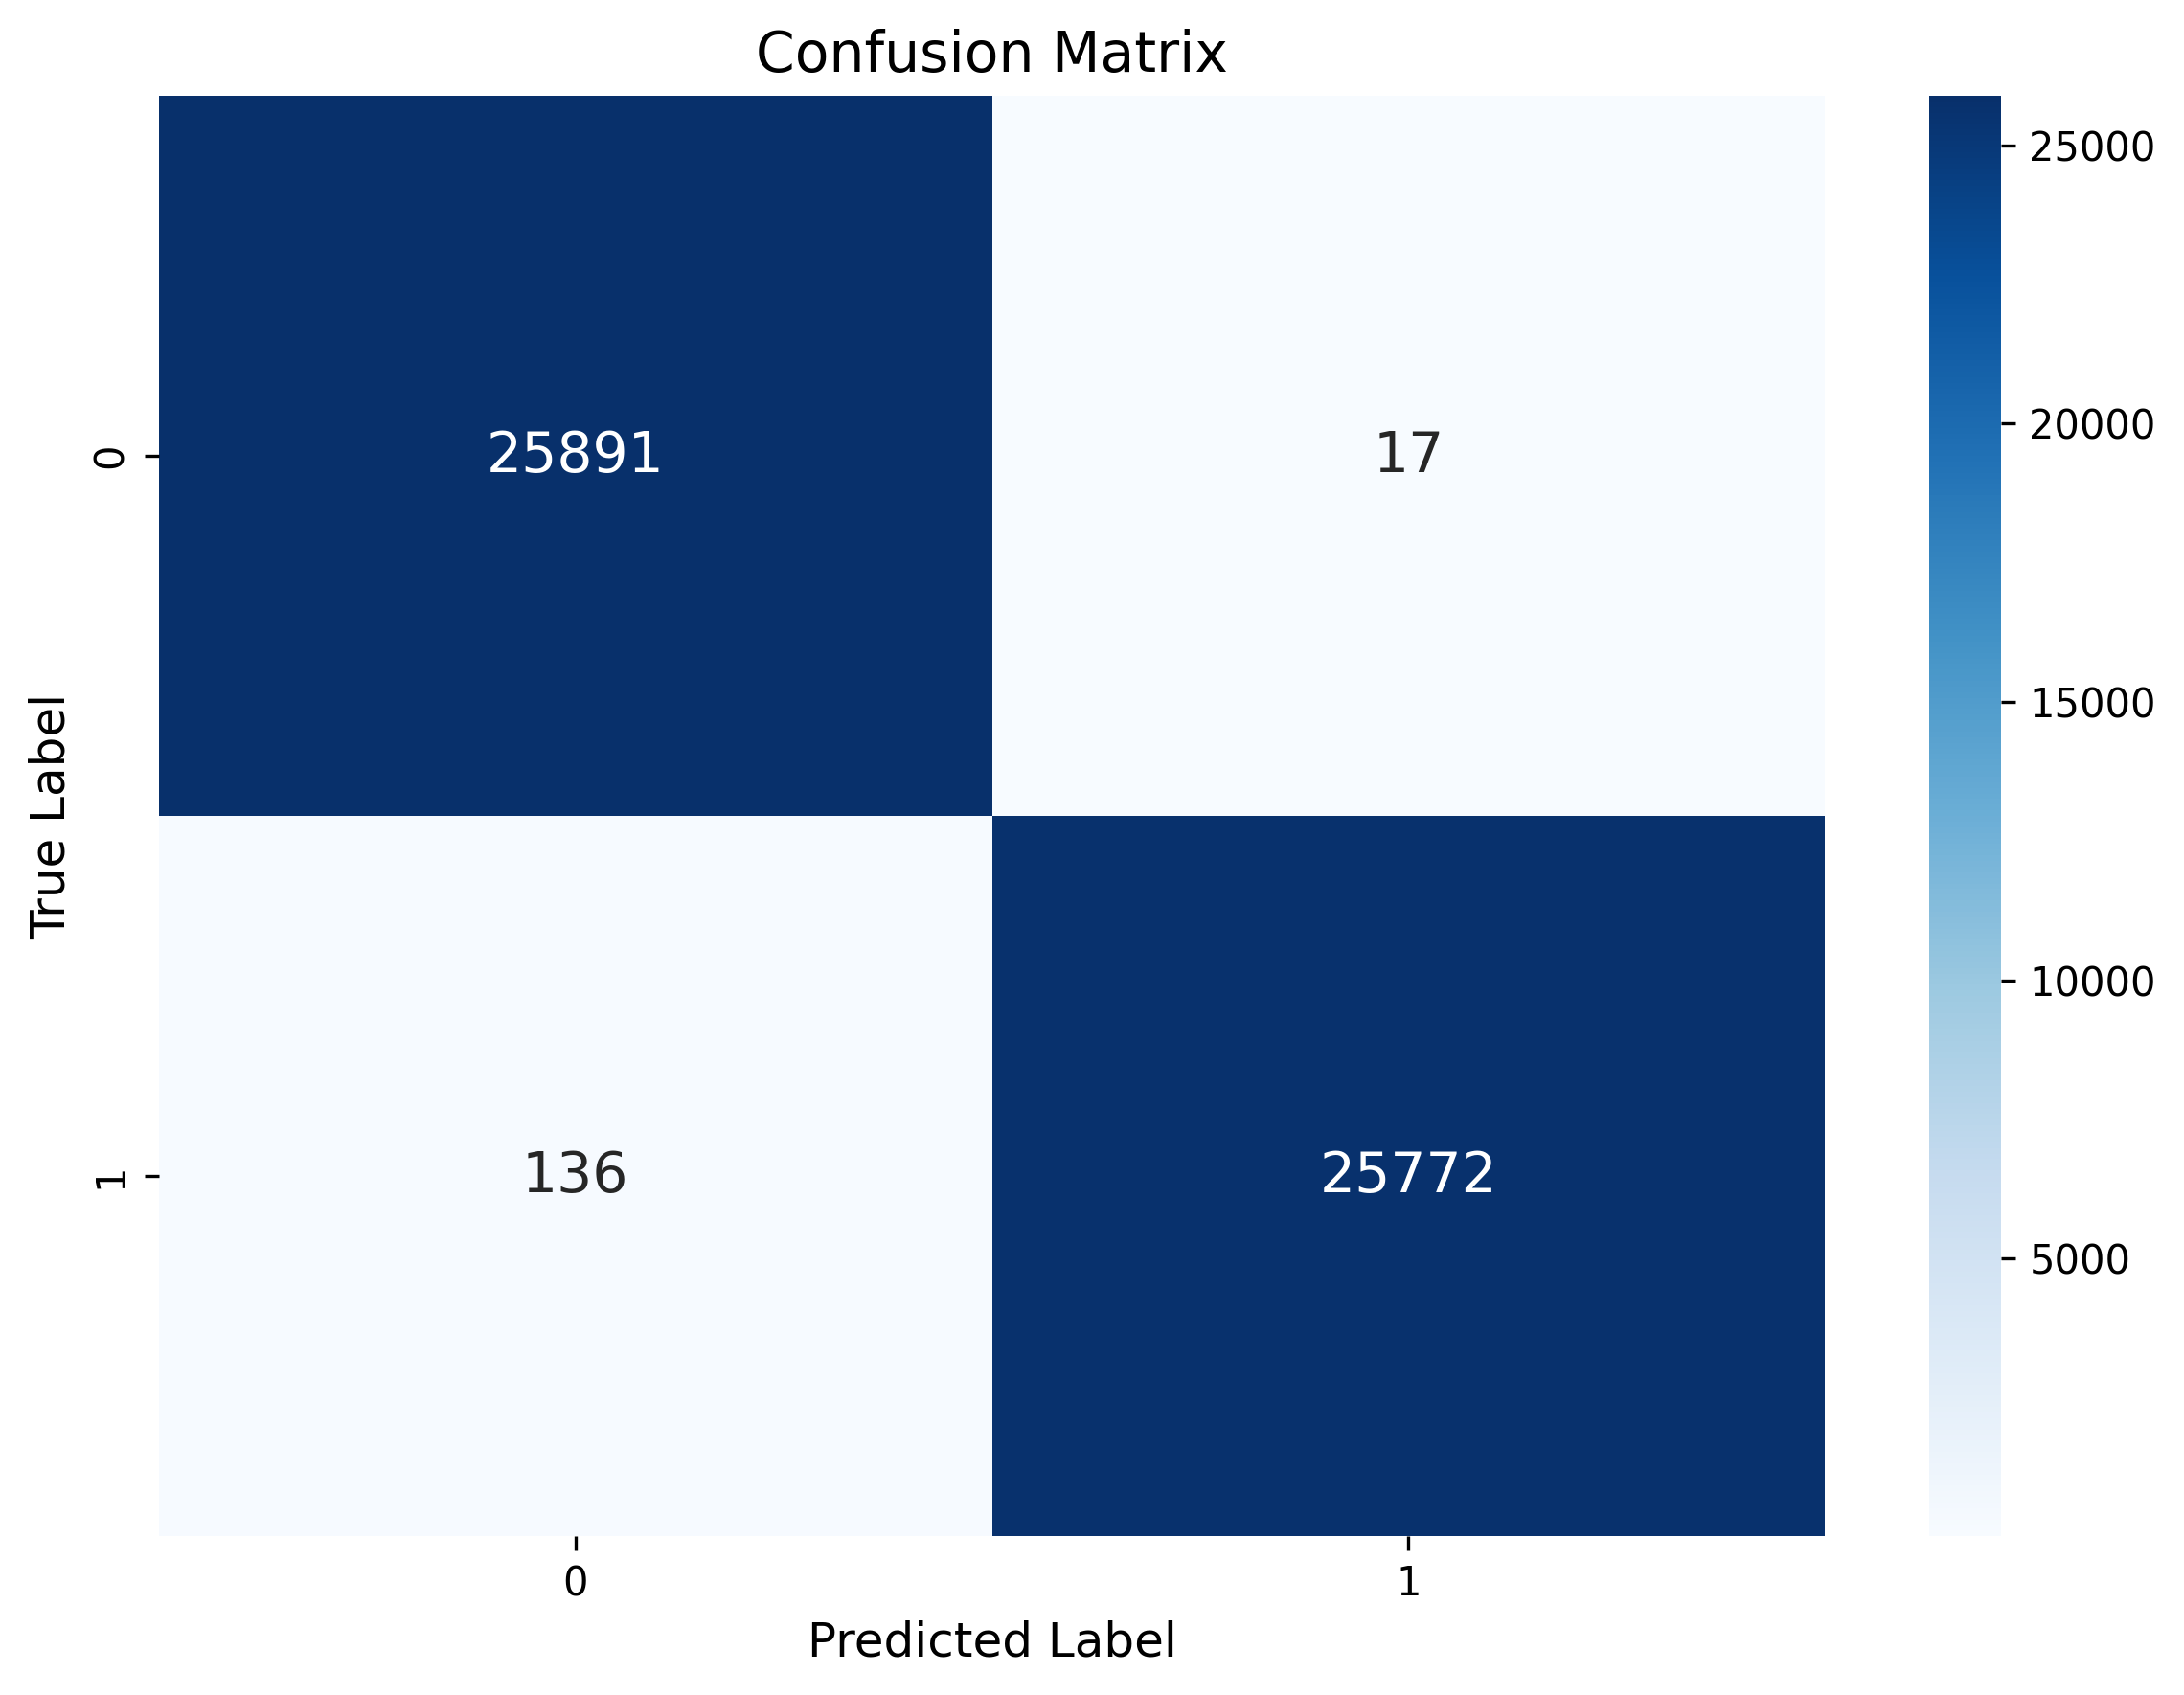

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(
    figsize=(8,6),
    dpi=300
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    annot_kws={"size":14}
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

plt.title(
    "Confusion Matrix",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure4_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

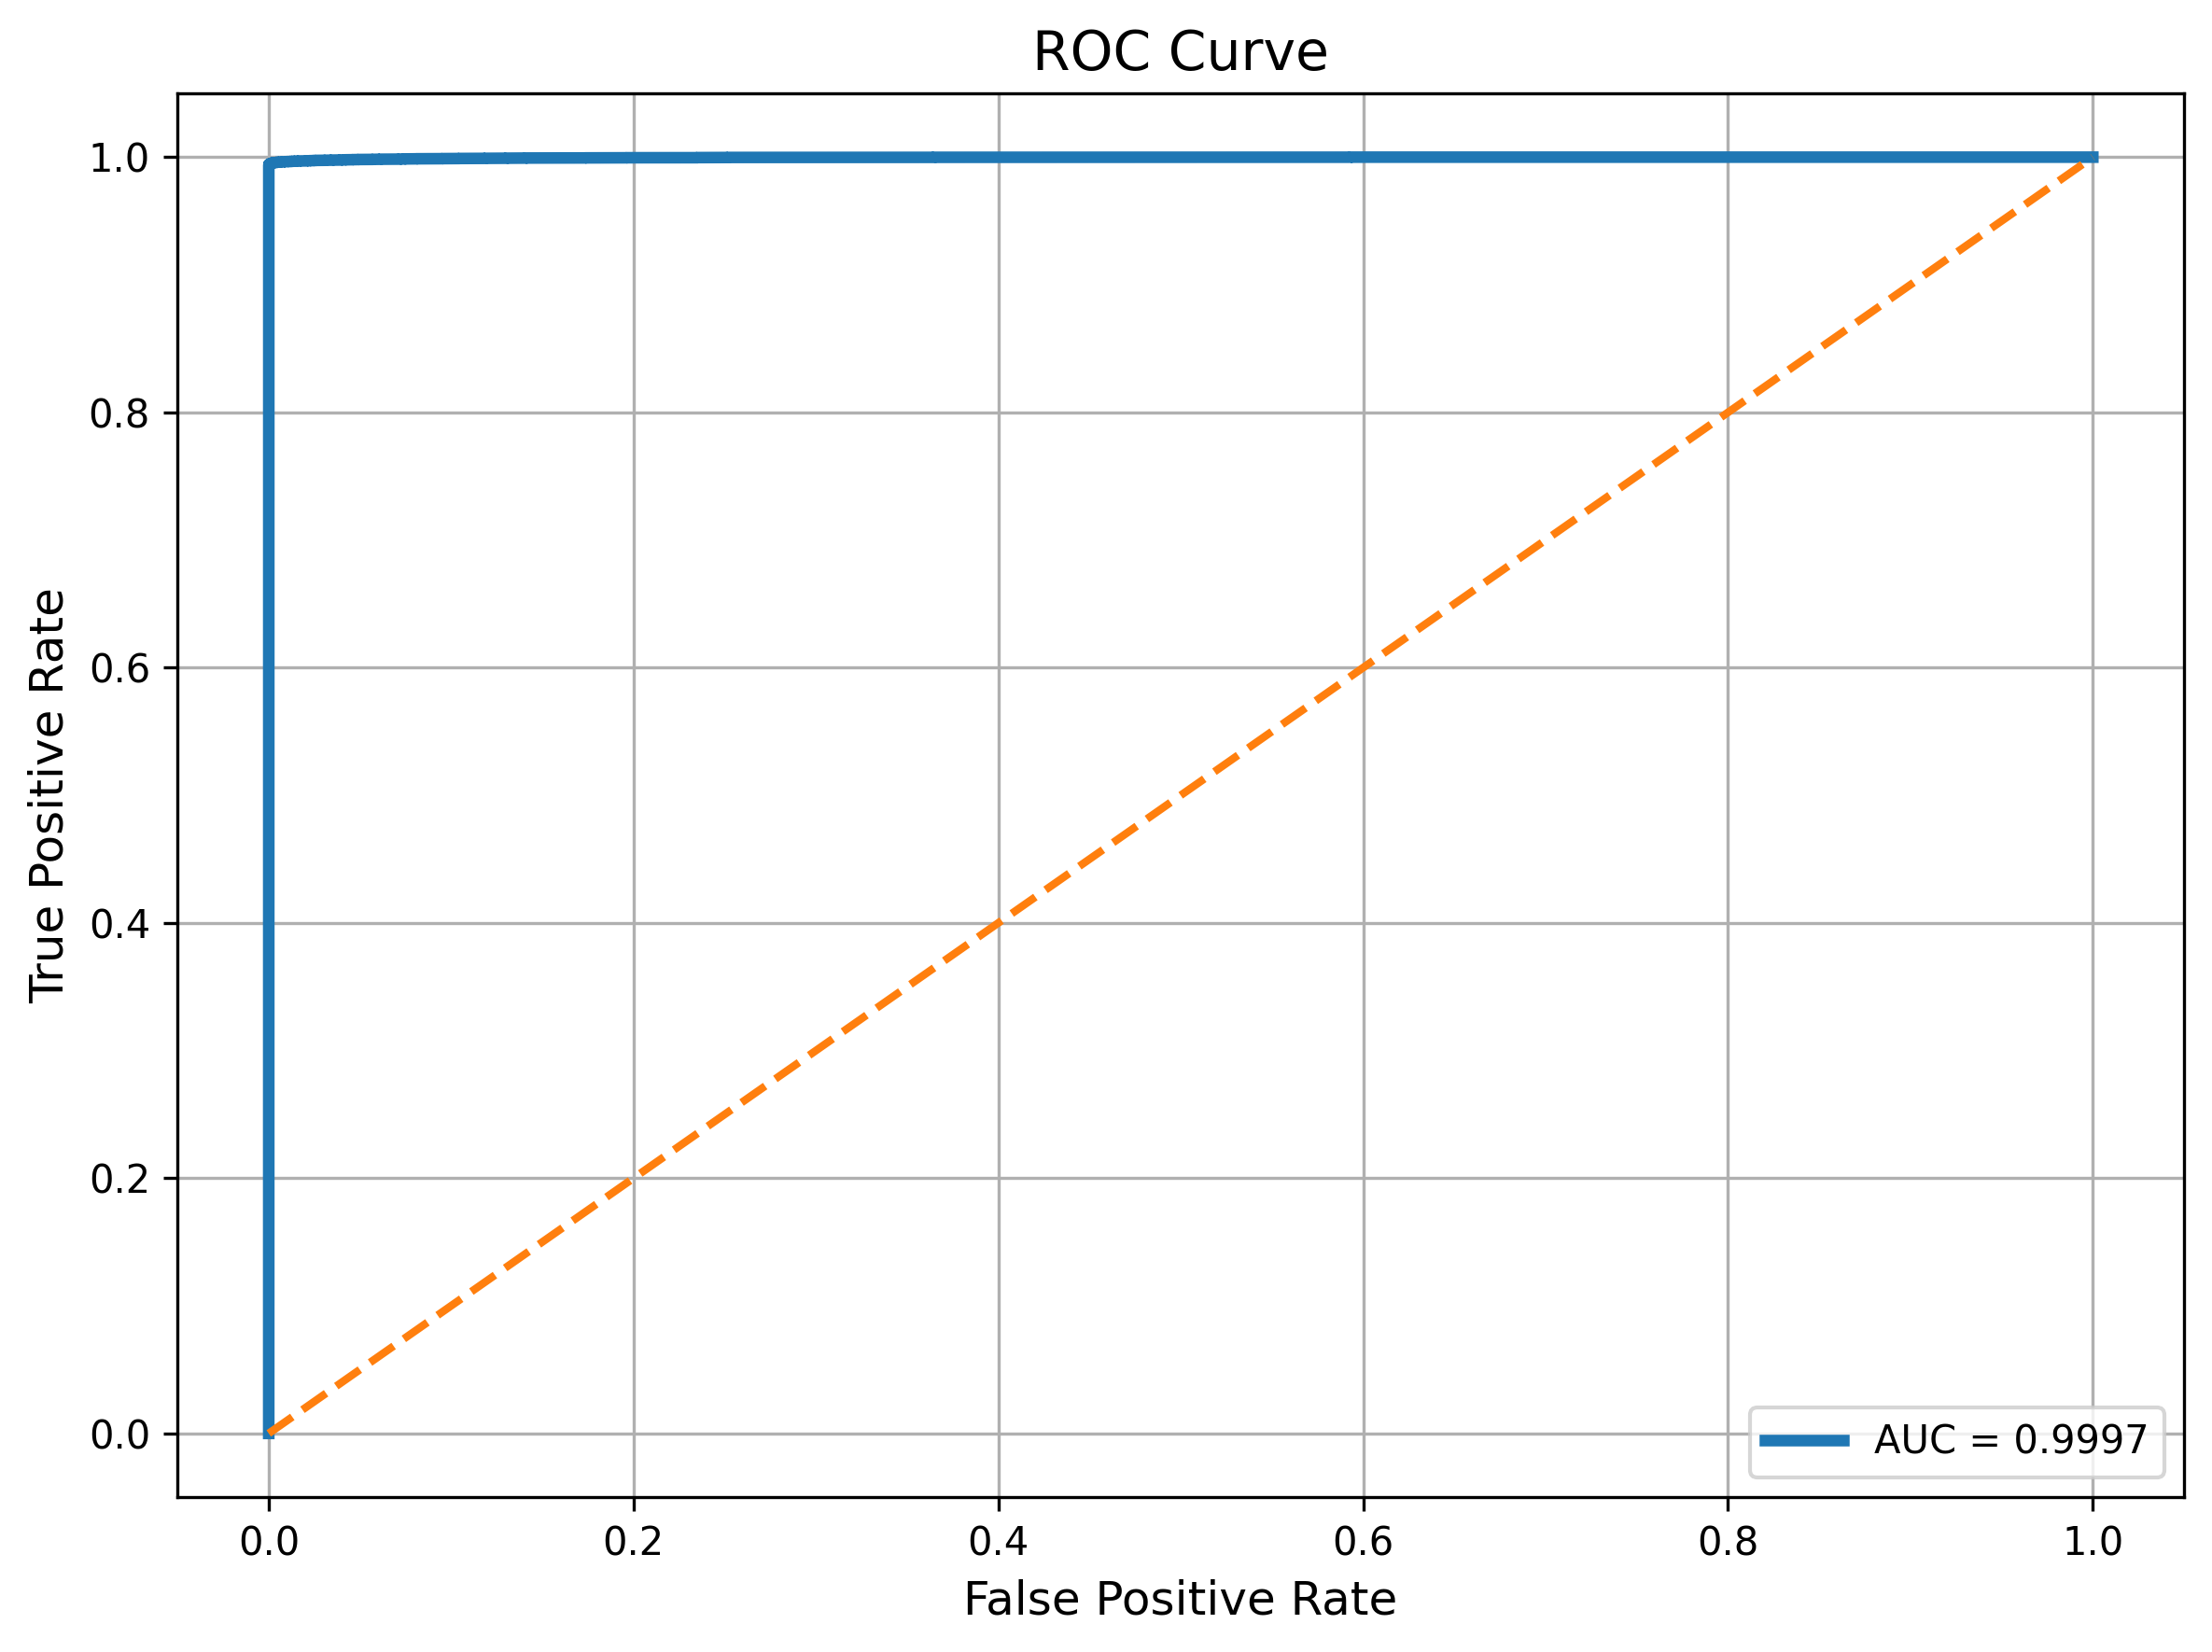

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, _ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(
    figsize=(8,6),
    dpi=300
)

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve",
    fontsize=14
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figure5_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

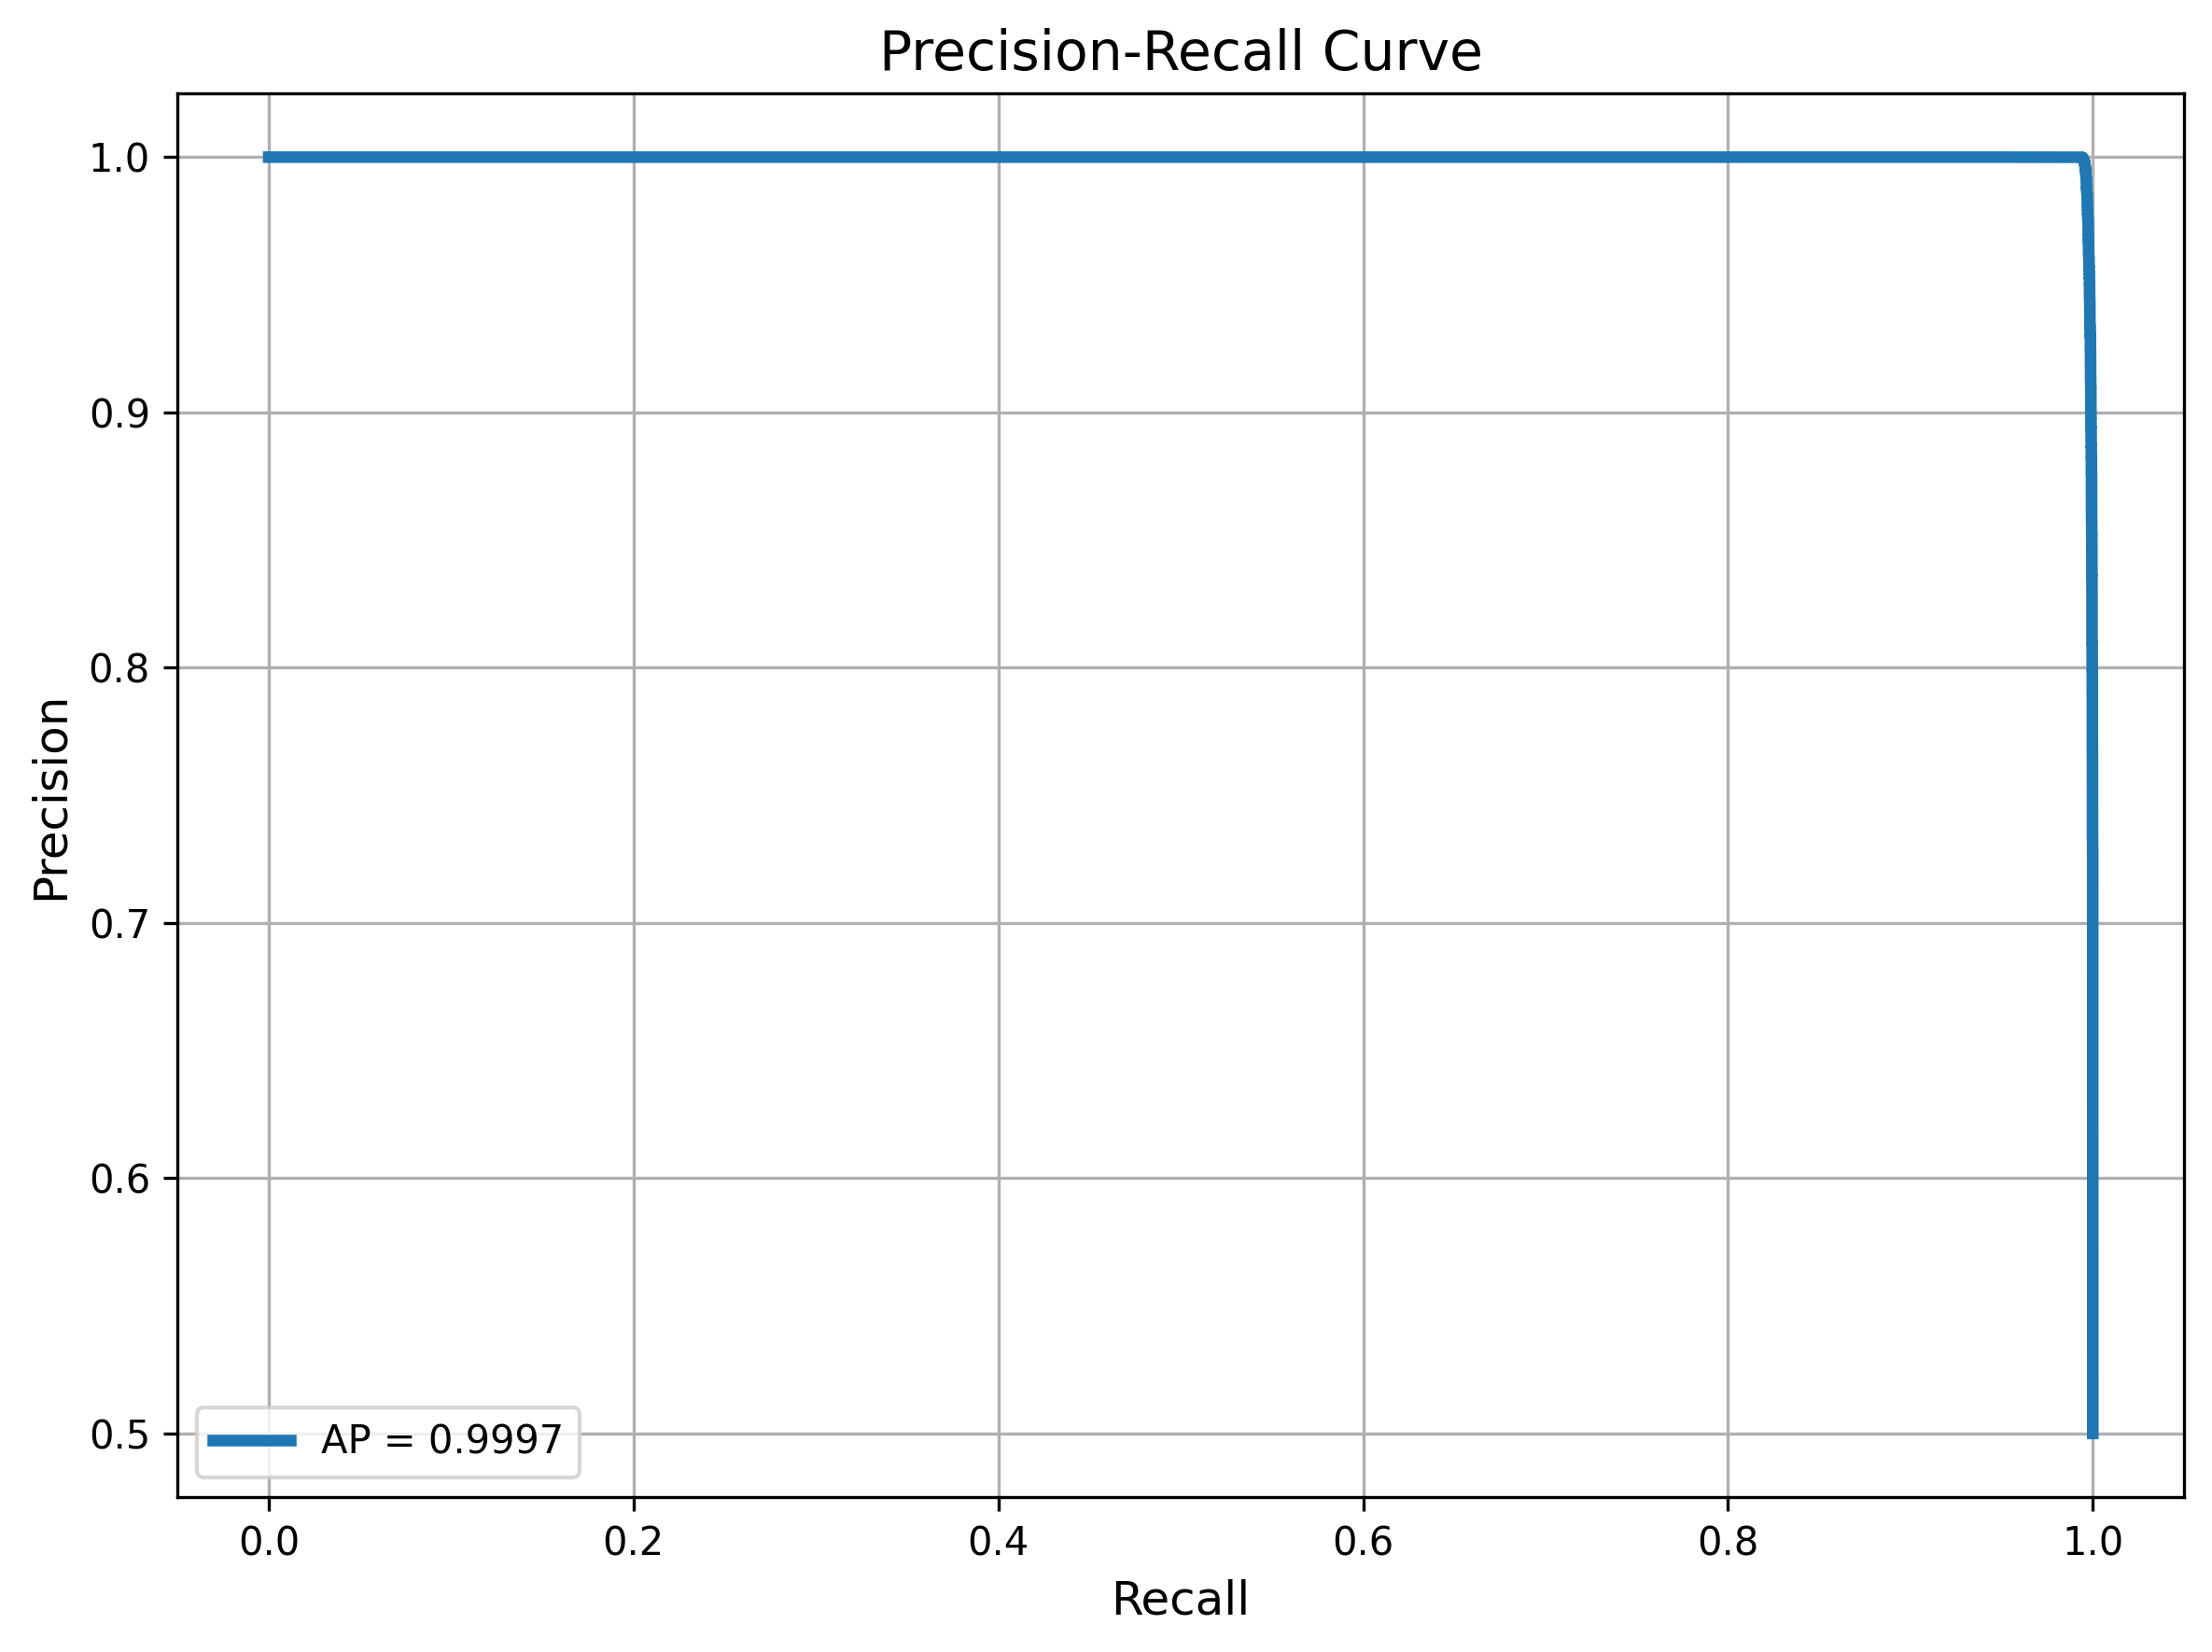

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(
    y_test,
    prob
)

ap = average_precision_score(
    y_test,
    prob
)

plt.figure(
    figsize=(8,6),
    dpi=300
)

plt.plot(
    recall,
    precision,
    linewidth=3,
    label=f"AP = {ap:.4f}"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Precision-Recall Curve",
    fontsize=14
)

plt.legend(
    loc="lower left"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figure6_PR_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

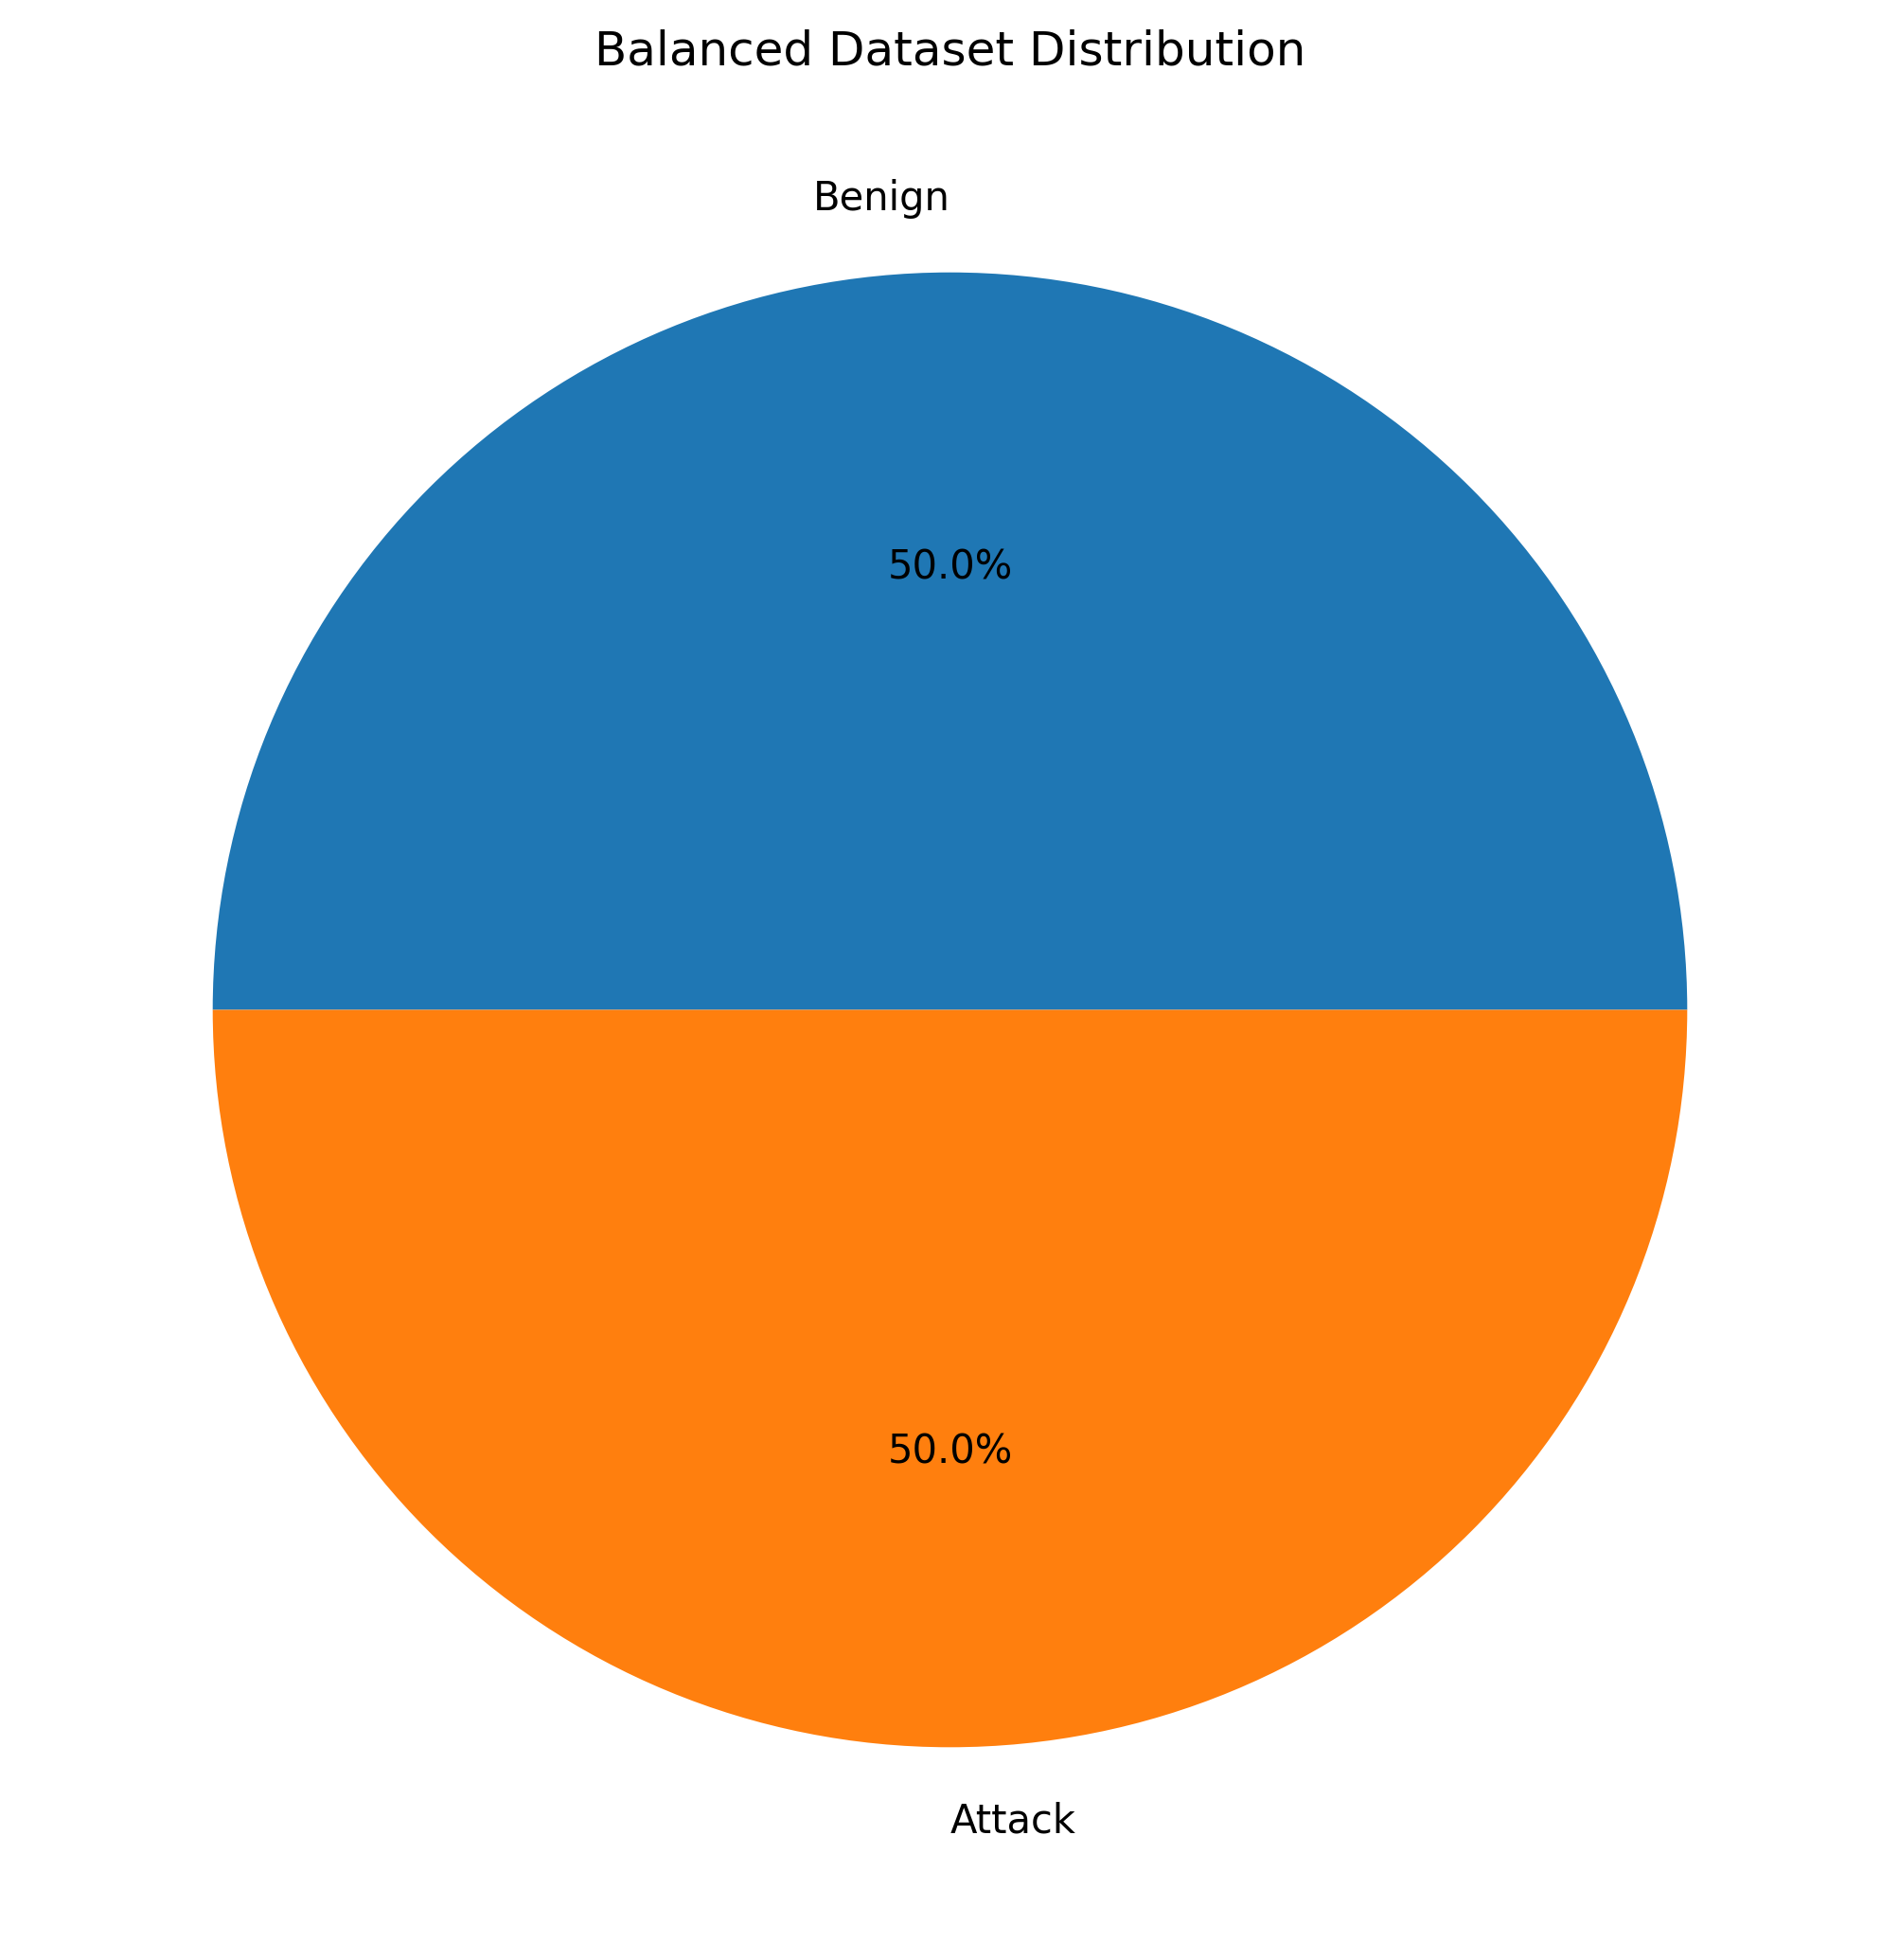

In [72]:
import matplotlib.pyplot as plt

counts = balanced_df["attack"].value_counts()

plt.figure(
    figsize=(7,7),
    dpi=300
)

plt.pie(
    counts,
    labels=[
        "Benign",
        "Attack"
    ],
    autopct="%1.1f%%"
)

plt.title(
    "Balanced Dataset Distribution"
)

plt.tight_layout()

plt.savefig(
    "Figure1_DatasetDistribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
table1 = pd.DataFrame({
    "Property":[
        "Dataset Name",
        "Total Samples",
        "Total Features",
        "Attack Samples",
        "Benign Samples",
        "Attack Classes"
    ],
    "Value":[
        "CICIoT2023",
        len(df),
        df.shape[1]-1,
        (df["label"]!="BenignTraffic").sum(),
        (df["label"]=="BenignTraffic").sum(),
        df["label"].nunique()-1
    ]
})

print(table1)

table1.to_csv(
    "Table1_DatasetDescription.csv",
    index=False
)

         Property       Value
0    Dataset Name  CICIoT2023
1   Total Samples     5491971
2  Total Features          47
3  Attack Samples     5362433
4  Benign Samples      129538
5  Attack Classes          33


In [74]:
table4 = packet_df.copy()

print(table4)

table4.to_csv(
    "Table4_RouteEvaluation.csv",
    index=False
)

                   route     trust  hops    pdr  packet_loss
5    [8, 30, 23, 46, 41]  0.840000     4  0.388        0.612
0     [8, 30, 23, 7, 41]  0.826000     4  0.340        0.660
1     [8, 30, 38, 7, 41]  0.776000     4  0.272        0.728
8    [8, 30, 38, 46, 41]  0.790000     4  0.265        0.735
2    [8, 30, 23, 33, 41]  0.780000     4  0.244        0.756
6    [8, 30, 44, 46, 41]  0.754000     4  0.212        0.788
3     [8, 30, 44, 7, 41]  0.740000     4  0.194        0.806
7    [8, 30, 38, 33, 41]  0.730000     4  0.178        0.822
4    [8, 30, 38, 11, 41]  0.714000     4  0.162        0.838
9  [8, 1, 27, 20, 7, 41]  0.663333     5  0.068        0.932


In [75]:
table4 = packet_df.copy()

table4["throughput"] = (
    table4["pdr"] * 1024
)

table4["delay"] = (
    table4["hops"] /
    table4["trust"]
)

print(table4)

table4.to_csv(
    "Table4_RouteEvaluation_Full.csv",
    index=False
)

                   route     trust  hops    pdr  packet_loss  throughput  \
5    [8, 30, 23, 46, 41]  0.840000     4  0.388        0.612     397.312   
0     [8, 30, 23, 7, 41]  0.826000     4  0.340        0.660     348.160   
1     [8, 30, 38, 7, 41]  0.776000     4  0.272        0.728     278.528   
8    [8, 30, 38, 46, 41]  0.790000     4  0.265        0.735     271.360   
2    [8, 30, 23, 33, 41]  0.780000     4  0.244        0.756     249.856   
6    [8, 30, 44, 46, 41]  0.754000     4  0.212        0.788     217.088   
3     [8, 30, 44, 7, 41]  0.740000     4  0.194        0.806     198.656   
7    [8, 30, 38, 33, 41]  0.730000     4  0.178        0.822     182.272   
4    [8, 30, 38, 11, 41]  0.714000     4  0.162        0.838     165.888   
9  [8, 1, 27, 20, 7, 41]  0.663333     5  0.068        0.932      69.632   

      delay  
5  4.761905  
0  4.842615  
1  5.154639  
8  5.063291  
2  5.128205  
6  5.305040  
3  5.405405  
7  5.479452  
4  5.602241  
9  7.537688  


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9948    0.9993    0.9971     25908
           1     0.9993    0.9948    0.9970     25908

    accuracy                         0.9970     51816
   macro avg     0.9971    0.9970    0.9970     51816
weighted avg     0.9971    0.9970    0.9970     51816



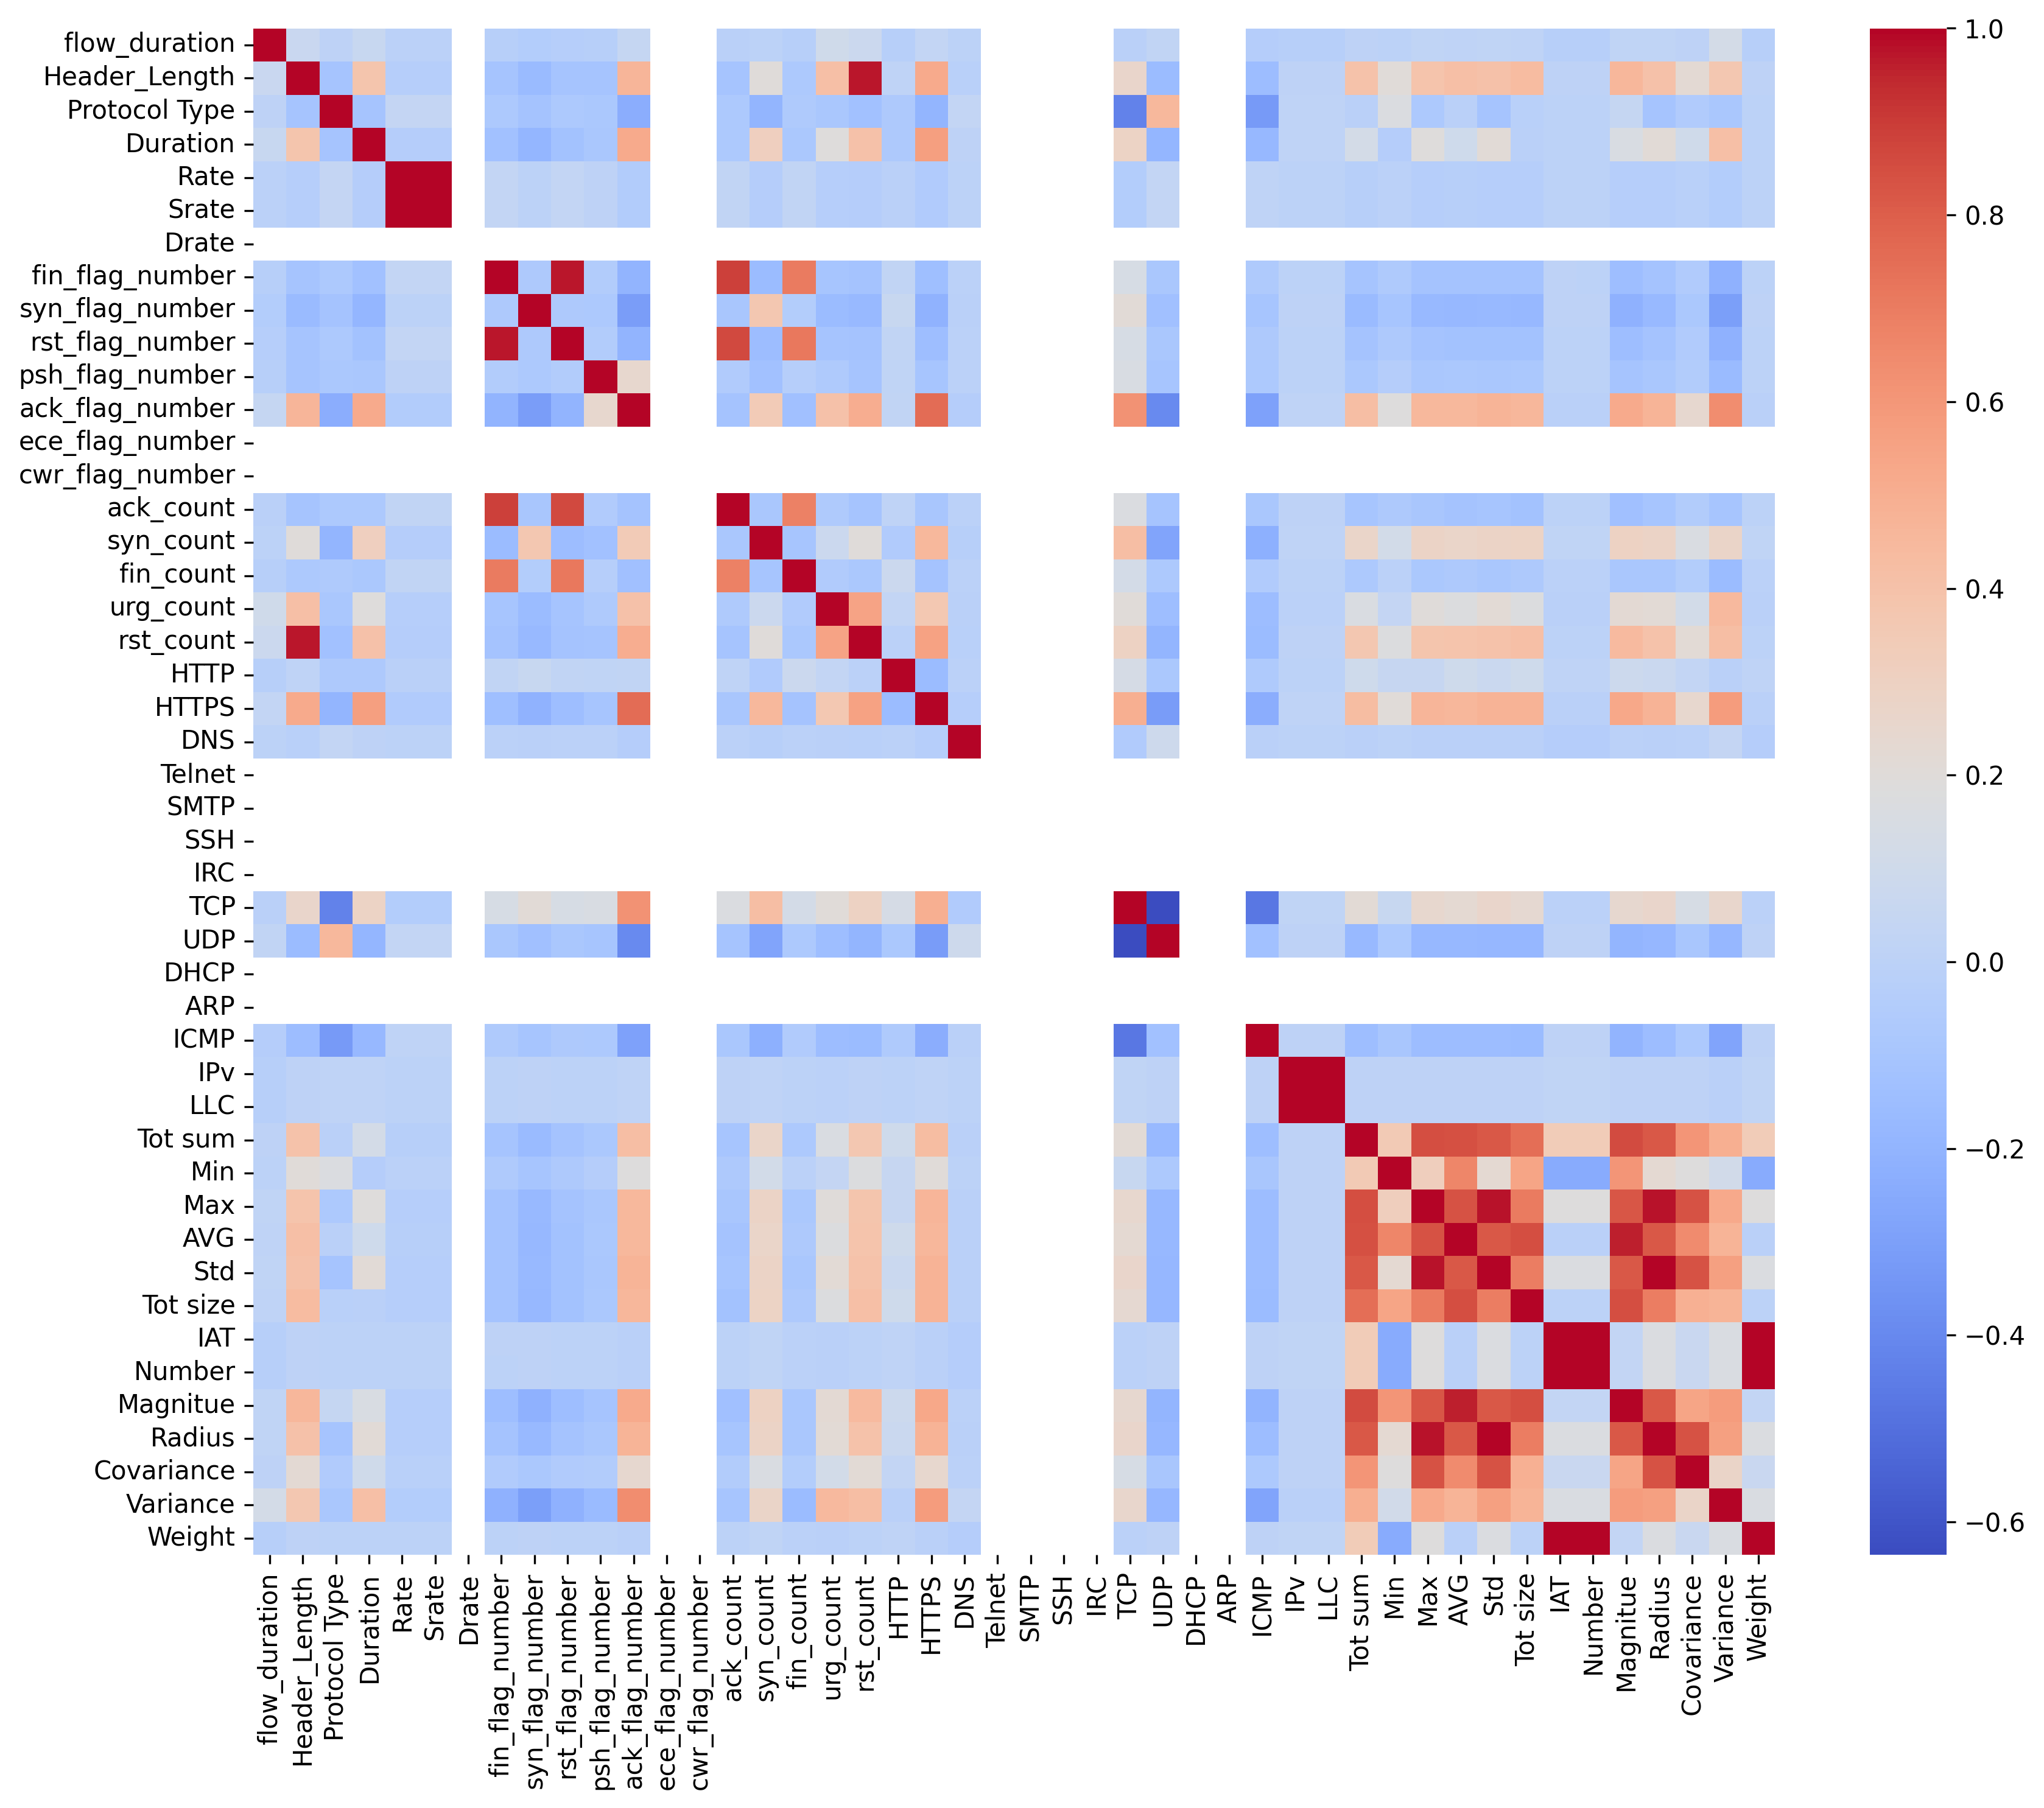

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,10),
    dpi=300
)

sns.heatmap(
    X.sample(5000).corr(),
    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig(
    "CorrelationHeatmap.png",
    dpi=300
)

plt.show()

In [82]:
print(type(y))
print(y)

<class 'float'>
389.12


In [84]:
X = balanced_df.drop(
    columns=["label", "attack"]
)

y = balanced_df["attack"]

print(type(y))
print(y.shape)

<class 'pandas.core.series.Series'>
(259076,)


In [85]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)

print("Mean Accuracy:", scores.mean())
print("Std Accuracy :", scores.std())

[0.99644897 0.9964875  0.99698929 0.99681559 0.99712438]
Mean Accuracy: 0.9967731488990706
Std Accuracy : 0.00026779386717757866


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Accuracy : 0.9963717770572796
Precision: 0.9999611227742788
Recall   : 0.9927821522309711
F1 Score : 0.9963587061785784
ROC AUC  : 0.9994976166422921


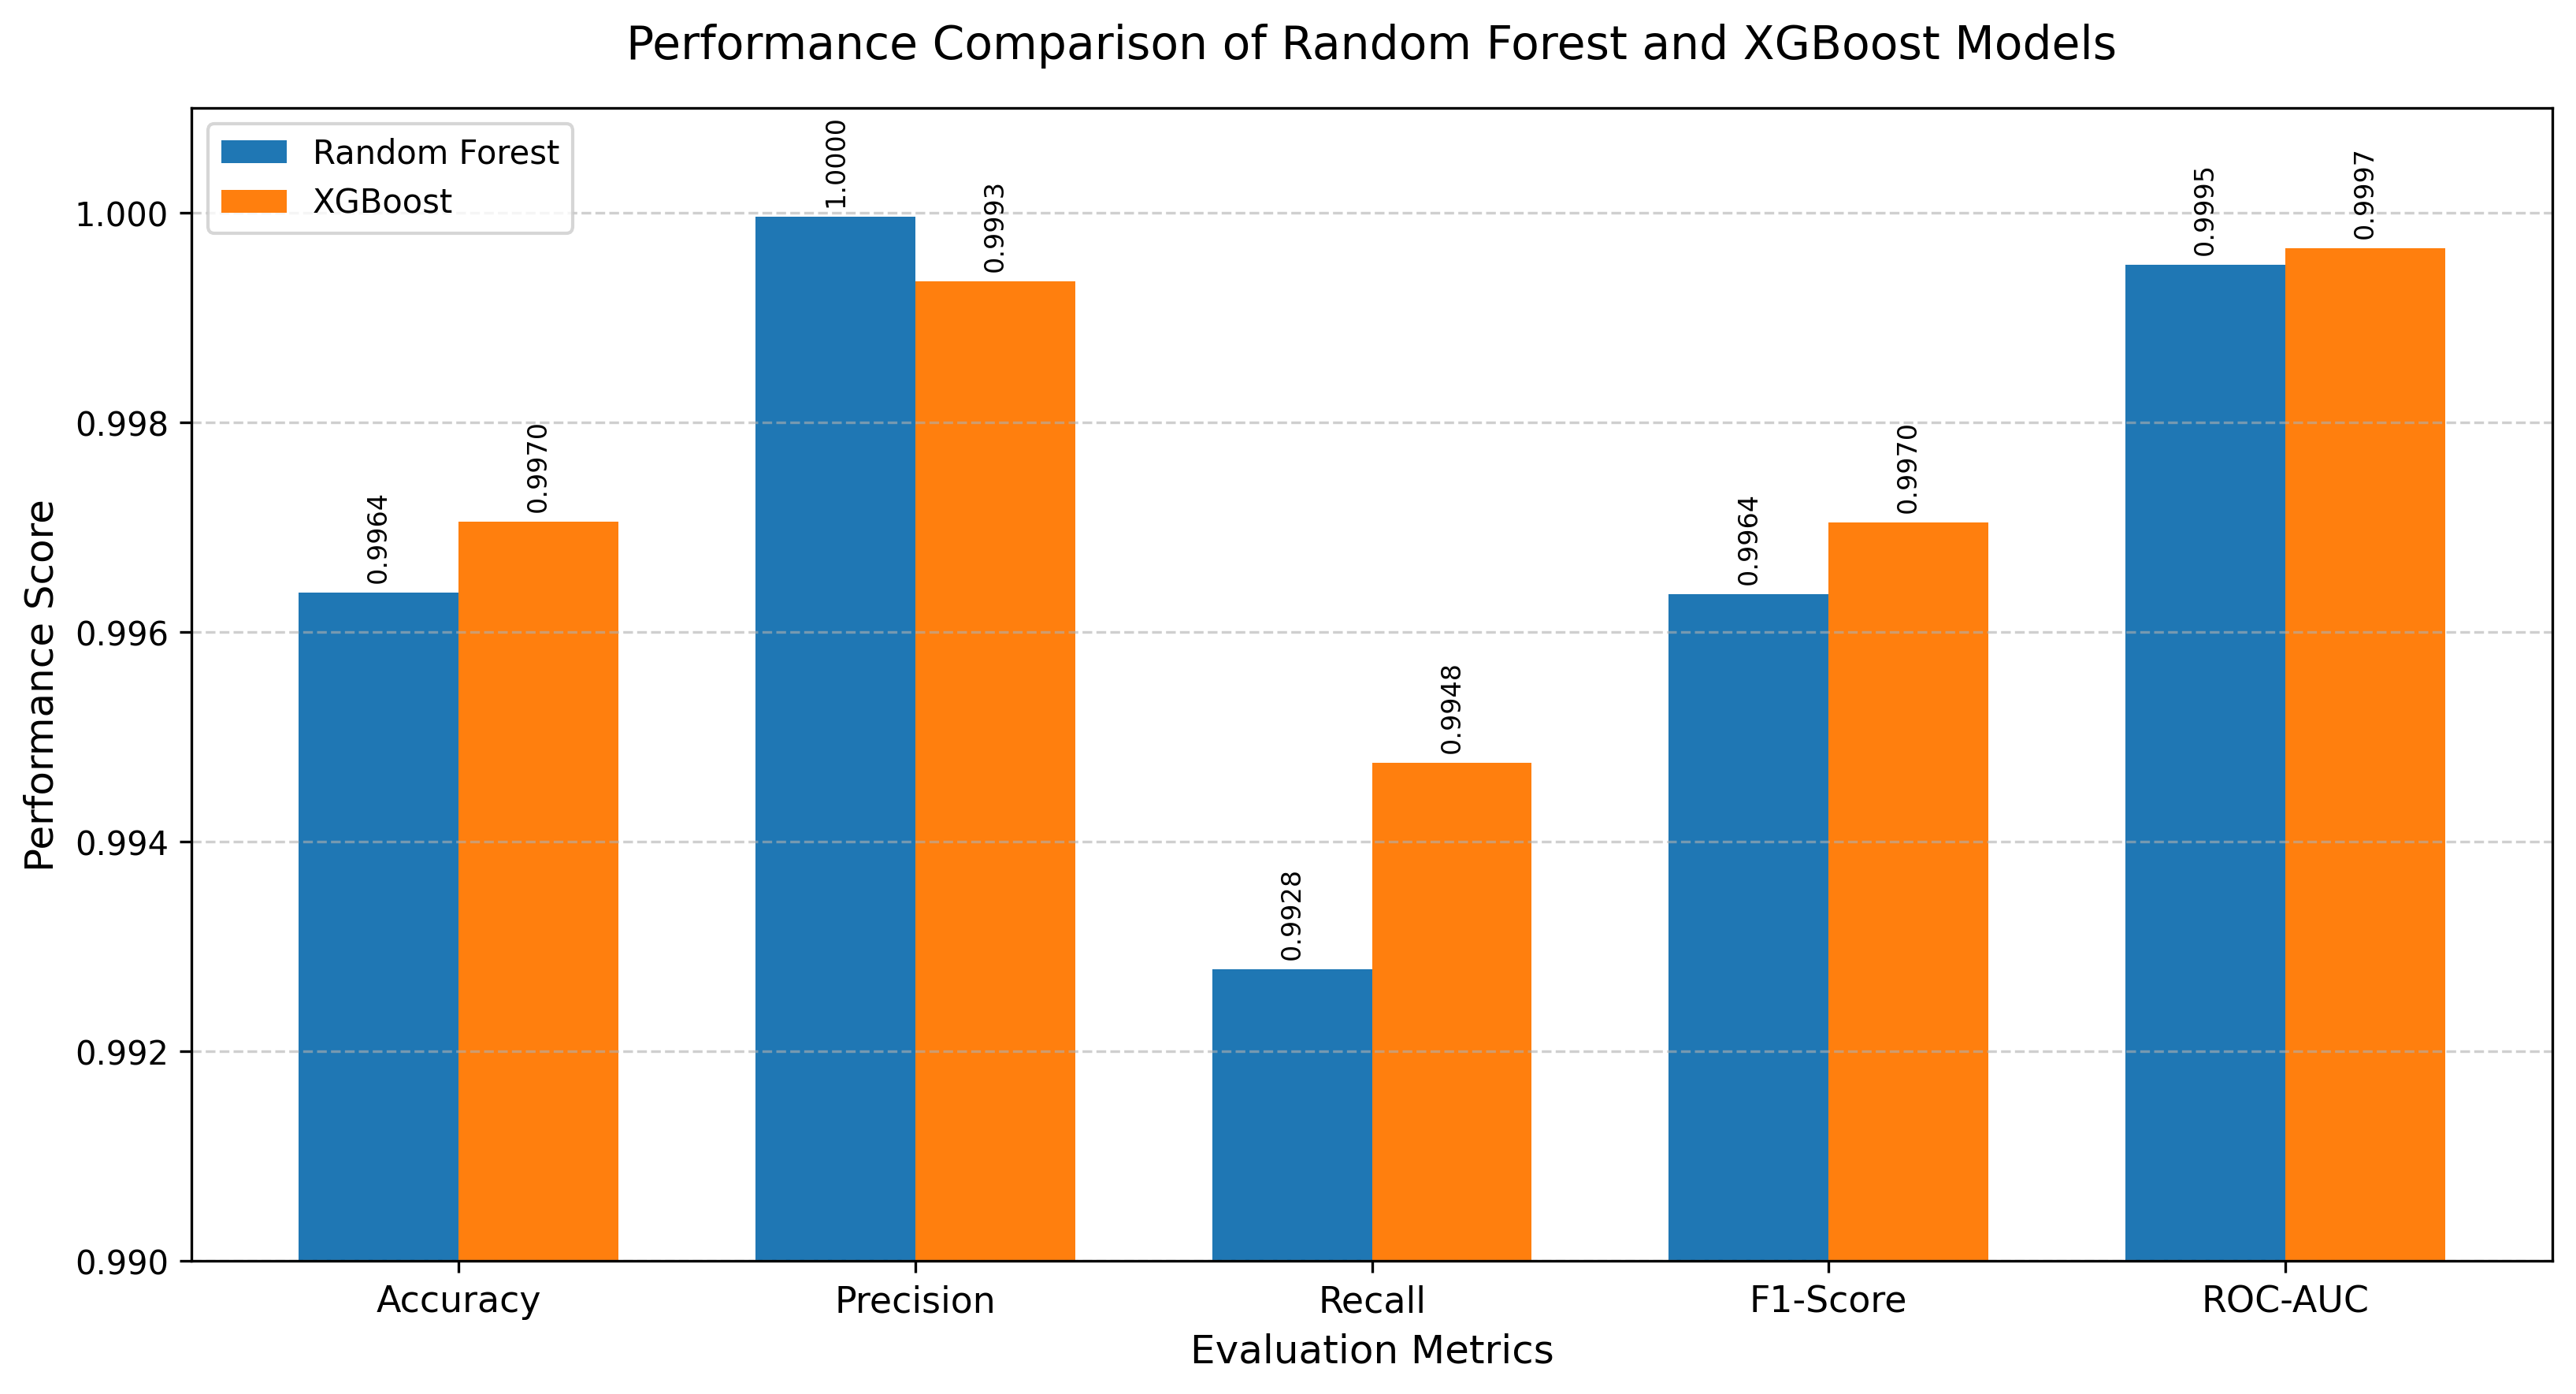

In [87]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

rf_scores = [
    0.9963717770572796,
    0.9999611227742788,
    0.9927821522309711,
    0.9963587061785784,
    0.9994976166422921
]

xgb_scores = [
    0.9970472440944882,
    0.999340804218853,
    0.994750656167979,
    0.9970404472213088,
    0.9996578715283536
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(
    figsize=(11,6),
    dpi=300
)

bars1 = plt.bar(
    x - width/2,
    rf_scores,
    width,
    label="Random Forest"
)

bars2 = plt.bar(
    x + width/2,
    xgb_scores,
    width,
    label="XGBoost"
)

for bar in bars1:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.00015,
        f"{height:.4f}",
        ha="center",
        fontsize=8,
        rotation=90
    )

for bar in bars2:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.00015,
        f"{height:.4f}",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.xticks(
    x,
    metrics,
    fontsize=11
)

plt.ylabel(
    "Performance Score",
    fontsize=12
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=12
)

plt.title(
    "Performance Comparison of Random Forest and XGBoost Models",
    fontsize=14,
    pad=15
)

plt.ylim(
    0.99,
    1.001
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    "Figure12_RF_vs_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()